# ENVY Class Smell Detection
## Consolidated Notebook: Rules → Traditional ML → TabPFN → Ensemble
### GroupKFold cross-validation | All methods | Deployment-ready

| Input | Path |
|---|---|
| Industrial | `drive/MyDrive/codesmell/data/smellycodefull.csv` |
| Student    | `drive/MyDrive/codesmell/data/student_features_with_labels.csv` |
| Output     | `drive/MyDrive/codesmellimprovements/god_class/` |

label_data_class ,label_long_method ,label_feature_envy

In [ ]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
!pip install xgboost imbalanced-learn scikit-learn joblib pandas numpy -q
!pip install tabpfn -q
!pip install lightgbm -q
print("All packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.8/229.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
All packages installed.


In [ ]:
# ── Cell 2: Imports + Drive mount + Global storage ───────────────────────────
import os, json, warnings, joblib, pickle
import numpy  as np
import pandas as pd
import xgboost as xgb
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set TabPFN token before any tabpfn import
os.environ["TABPFN_TOKEN"] = ""
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from sklearn.ensemble          import RandomForestClassifier
from sklearn.tree              import DecisionTreeClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.preprocessing     import StandardScaler
from sklearn.model_selection   import GroupKFold, StratifiedKFold
from sklearn.metrics           import (
    f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve
)
from imblearn.combine          import SMOTETomek, SMOTEENN
from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline as ImbPipeline

# ── Global OOF accumulator ────────────────────────────────────────────────────
# Each method cell populates:
#   ALL_RESULTS[model_name] = {'prob': np.array, 'pred_05': np.array, 'category': str}
ALL_RESULTS = {}

print(f"XGBoost {xgb.__version__}  ready")
print("ALL_RESULTS dict initialised — ready to accumulate OOF predictions.")

Mounted at /content/drive
XGBoost 3.2.0  ready
ALL_RESULTS dict initialised — ready to accumulate OOF predictions.


In [ ]:
# ── Cell 3: Paths, constants, feature columns ────────────────────────────────
BASE      = '/content/drive/MyDrive/codesmell'
IND_DATA  = f'{BASE}/data/smellycodefull.csv'
STUD_DATA = f'{BASE}/data/student_features_with_labels.csv'

OUT_BASE   = '/content/drive/MyDrive/CodeSmell_Stage3/feature_envy'
P1_MODELS  = f'{OUT_BASE}/phase1/models'
P1_RESULTS = f'{OUT_BASE}/phase1/results'
PA_MODELS  = f'{OUT_BASE}/modelA/models'
PA_RESULTS = f'{OUT_BASE}/modelA/results'
PT_MODELS  = f'{OUT_BASE}/trAda/models'
PT_RESULTS = f'{OUT_BASE}/trAda/results'
DEPLOY_DIR = f'{OUT_BASE}/deployment'

for d in [P1_MODELS, P1_RESULTS, PA_MODELS, PA_RESULTS,
          PT_MODELS, PT_RESULTS, DEPLOY_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    'Logical Lines', 'Distinct Operators', 'Distinct Operands',
    'Total Operators', 'Total Operands', 'Cyclomatic Complexity',
]
TARGET      =  'label_feature_envy'
IND_LABEL   = 'Feature envy'
IND_PROJECT = 'Project'

print("Paths configured.")
print(f"  Industrial data : {IND_DATA}")
print(f"  Student data    : {STUD_DATA}")
print(f"  Output base     : {OUT_BASE}")

Paths configured.
  Industrial data : /content/drive/MyDrive/codesmell/data/smellycodefull.csv
  Student data    : /content/drive/MyDrive/codesmell/data/student_features_with_labels.csv
  Output base     : /content/drive/MyDrive/CodeSmell_Stage3/feature_envy


In [ ]:
# ── Cell 4: Load industrial + student data ───────────────────────────────────
# ── Industrial ────────────────────────────────────────────────────────────────
df_ind = pd.read_csv(IND_DATA)
missing_ind = [c for c in FEATURE_COLS + [IND_LABEL, IND_PROJECT] if c not in df_ind.columns]
if missing_ind:
    raise ValueError(f"Industrial data missing columns: {missing_ind}")

df_ind[FEATURE_COLS] = df_ind[FEATURE_COLS].fillna(0)
X_ind = df_ind[FEATURE_COLS].values
y_ind = df_ind[IND_LABEL].values.astype(int)
g_ind = df_ind[IND_PROJECT].values
pos_i = int(y_ind.sum())
print(f"Industrial : {df_ind.shape[0]:,} samples | {pos_i} Feature envy ({pos_i/len(y_ind)*100:.1f}%)")
print(f"  Projects : {df_ind[IND_PROJECT].nunique()}")

# ── Student ────────────────────────────────────────────────────────────────────
df_stu = pd.read_csv(STUD_DATA)
missing_stu = [c for c in FEATURE_COLS + [TARGET, 'project'] if c not in df_stu.columns]
if missing_stu:
    raise ValueError(f"Student data missing columns: {missing_stu}")

df_stu = df_stu.dropna(subset=FEATURE_COLS + [TARGET]).reset_index(drop=True)
df_stu[TARGET] = df_stu[TARGET].astype(int)

X_all      = df_stu[FEATURE_COLS].values.astype(float)
y_all      = df_stu[TARGET].values.astype(int)
groups_all = df_stu['project'].values
n_all      = len(df_stu)
n_pos_all  = int(y_all.sum())
n_repos    = df_stu['project'].nunique()

print(f"\nStudent    : {n_all:,} samples | {n_pos_all} Feature envy ({n_pos_all/n_all*100:.1f}%)")
print(f"  Projects : {n_repos}")

# ── Per-repo summary ──────────────────────────────────────────────────────────
print("\nPer-repo positives:")
for repo, grp in df_stu.groupby('project'):
    p = int(grp[TARGET].sum())
    print(f"  {repo:45s}  {p:2d}  {'█'*p}")

# ── GroupKFold setup (shared by all subsequent cells) ─────────────────────────
N_SPLITS = min(5, n_repos)
while N_SPLITS > 2 and n_pos_all / N_SPLITS < 1.5:
    N_SPLITS -= 1
gkf = GroupKFold(n_splits=N_SPLITS)
print(f"\nGroupKFold: n_splits={N_SPLITS}  total_pos={n_pos_all}  ~pos/fold={n_pos_all/N_SPLITS:.1f}")

Industrial : 107,554 samples | 1996 Feature envy (1.9%)
  Projects : 89

Student    : 3,266 samples | 102 Feature envy (3.1%)
  Projects : 821

Per-repo positives:
  20+Java-Question-lab-work                       0  
  4sum.java                                       0  
  A.java                                          0  
  AES.java                                        0  
  AI Riddle Game                                  0  
  API-Lesson1                                     0  
  ATM                                             0  
  ATM System                                      0  
  ATM interface                                   0  
  ATM-Bankomat                                    0  
  ATM2-Bankomat                                   0  
  AbstractClassesAndMethods                       0  
  Abstraction & Interfaces.java                   0  
  AccessModifiers                                 0  
  Addhar entry                                    1  █
  Address Book           

In [ ]:
# ── Cell 5: Model_I — Train on industrial data, save .joblib, extract booster ─
# Used as: (a) zero-shot transfer baseline on student data
#          (b) starting checkpoint for TrAdaBoost (Cell 8)
print("="*72)
print("MODEL_I: Industrial data  |  GroupKFold/StratifiedKFold + SMOTETomek")
print("="*72)

n_proj = df_ind[IND_PROJECT].nunique()
if n_proj >= 5:
    cv_ind     = GroupKFold(n_splits=min(5, n_proj))
    split_args = (X_ind, y_ind, g_ind)
    cv_desc    = f"GroupKFold(n={min(5,n_proj)})"
else:
    cv_ind     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    split_args = (X_ind, y_ind)
    cv_desc    = "StratifiedKFold(n=5)"

def make_ind_pipe(clf):
    return ImbPipeline([
        ('scaler',   StandardScaler()),
        ('resample', SMOTETomek(random_state=RANDOM_STATE)),
        ('clf',      clf),
    ])

pipelines_I = {
    'LogisticRegression': make_ind_pipe(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
    'DecisionTree':       make_ind_pipe(
        DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE)),
    'RandomForest':       make_ind_pipe(
        RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=RANDOM_STATE, n_jobs=-1)),
    'XGBoost':            make_ind_pipe(
        xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                          eval_metric='logloss', random_state=RANDOM_STATE,
                          n_jobs=-1, verbosity=0)),
}

print(f"CV: {cv_desc}")
print(f"\n{'Model':22s}  {'F1':>6}  {'Prec':>6}  {'Rec':>6}  {'PR-AUC':>7}")
print("-"*56)

fitted_I = {}
for name, pipe in pipelines_I.items():
    yp  = np.zeros(len(y_ind), dtype=int)
    prb = np.zeros(len(y_ind))
    for tr, va in cv_ind.split(*split_args):
        Xtr, Xva, ytr = X_ind[tr], X_ind[va], y_ind[tr]
        if ytr.sum() < 2:
            continue
        pipe.fit(Xtr, ytr)
        yp[va]  = pipe.predict(Xva)
        prb[va] = pipe.predict_proba(Xva)[:, 1]
    pipe.fit(X_ind, y_ind)
    fitted_I[name] = pipe
    f1   = f1_score(y_ind, yp, zero_division=0)
    prec = precision_score(y_ind, yp, zero_division=0)
    rec  = recall_score(y_ind, yp, zero_division=0)
    pr   = average_precision_score(y_ind, prb)
    print(f"  {name:20s}  {f1:6.3f}  {prec:6.3f}  {rec:6.3f}  {pr:7.3f}")
    joblib.dump(pipe, f"{P1_MODELS}/model_I_envy_class_{name}.joblib")

pd.DataFrame([{
    'model': n, 'f1': round(f1_score(y_ind,np.zeros(len(y_ind),dtype=int)),3)
} for n in fitted_I]).to_csv(f"{P1_RESULTS}/phase1_results.csv", index=False)

# ── Extract XGBoost booster + industrial scaler (needed for TrAda in Cell 8) ─
model_I_xgb = fitted_I['XGBoost']
booster_I   = model_I_xgb.named_steps['clf'].get_booster()
ind_scaler  = model_I_xgb.named_steps['scaler']
joblib.dump(ind_scaler, f"{P1_MODELS}/ind_scaler.joblib")

print(f"\nModel_I saved → {P1_MODELS}")
print("booster_I + ind_scaler ready (used by TrAdaBoost in Cell 8)")

MODEL_I: Industrial data  |  GroupKFold/StratifiedKFold + SMOTETomek
CV: GroupKFold(n=5)

Model                       F1    Prec     Rec   PR-AUC
--------------------------------------------------------
  LogisticRegression     0.070   0.037   0.767    0.039
  DecisionTree           0.113   0.061   0.691    0.066
  RandomForest           0.189   0.152   0.250    0.106
  XGBoost                0.177   0.105   0.562    0.127

Model_I saved → /content/drive/MyDrive/CodeSmell_Stage3/feature_envy/phase1/models
booster_I + ind_scaler ready (used by TrAdaBoost in Cell 8)


In [ ]:
# ── Cell 6: Rule-based baselines — GroupKFold OOF on student data ────────────
# Rules derived from feature importance analysis (Logical Lines dominates).
# Rule1  — Single:  Logical Lines > P75
# Rule2  — AND:     LL > P75 AND Total Operands > P75 AND Distinct Operands > P75
# Rule3  — OR:      any feature > P90
# Rule4  — Scoring: LL>P75 (+3), TotalOp>P75 (+2), DistOp>P75 (+1),
#                   TotalOpR>P75 (+1), CC>P75 (+1) → predict if score >= 3
print("="*72)
print("RULE-BASED BASELINES")
print("="*72)

FEAT_IDX = {f: i for i, f in enumerate(FEATURE_COLS)}
ll_idx   = FEAT_IDX['Logical Lines']
do_idx   = FEAT_IDX['Distinct Operands']
toi_idx  = FEAT_IDX['Total Operators']
top_idx  = FEAT_IDX['Total Operands']
cc_idx   = FEAT_IDX['Cyclomatic Complexity']

rule_preds = {
    'Rule1_Single':  np.zeros(n_all, dtype=int),
    'Rule2_AND':     np.zeros(n_all, dtype=int),
    'Rule3_OR':      np.zeros(n_all, dtype=int),
    'Rule4_Score':   np.zeros(n_all, dtype=int),
}

for _, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups_all)):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    p75 = np.percentile(X_tr, 75, axis=0)
    p90 = np.percentile(X_tr, 90, axis=0)

    rule_preds['Rule1_Single'][va_idx] = (
        X_va[:, ll_idx] > p75[ll_idx]).astype(int)

    rule_preds['Rule2_AND'][va_idx] = (
        (X_va[:, ll_idx]  > p75[ll_idx]) &
        (X_va[:, top_idx] > p75[top_idx]) &
        (X_va[:, do_idx]  > p75[do_idx])
    ).astype(int)

    rule_preds['Rule3_OR'][va_idx] = np.any(
        X_va > p90[np.newaxis, :], axis=1).astype(int)

    score = (
        (X_va[:, ll_idx]  > p75[ll_idx]).astype(int)  * 3 +
        (X_va[:, top_idx] > p75[top_idx]).astype(int) * 2 +
        (X_va[:, do_idx]  > p75[do_idx]).astype(int)  * 1 +
        (X_va[:, toi_idx] > p75[toi_idx]).astype(int) * 1 +
        (X_va[:, cc_idx]  > p75[cc_idx]).astype(int)  * 1
    )
    rule_preds['Rule4_Score'][va_idx] = (score >= 3).astype(int)

print(f"\n{'Rule':20s}  {'F1':>6}  {'Prec':>6}  {'Rec':>6}  {'PR-AUC':>7}  {'TP':>3}  {'FP':>3}")
print("-"*62)

for rname, rpred in rule_preds.items():
    f1   = f1_score(y_all, rpred, zero_division=0)
    prec = precision_score(y_all, rpred, zero_division=0)
    rec  = recall_score(y_all, rpred, zero_division=0)
    pr   = average_precision_score(y_all, rpred.astype(float))
    cm   = confusion_matrix(y_all, rpred)
    tp, fp = cm[1,1], cm[0,1]
    print(f"  {rname:18s}  {f1:6.3f}  {prec:6.3f}  {rec:6.3f}  {pr:7.3f}  {tp:3d}  {fp:3d}")
    # Rules have no continuous probability; use binary pred as proxy
    ALL_RESULTS[rname] = {
        'prob':     rpred.astype(float),
        'pred_05':  rpred,
        'category': 'Rule'
    }

print(f"\nRule baselines → ALL_RESULTS ({len(ALL_RESULTS)} entries)")

RULE-BASED BASELINES

Rule                      F1    Prec     Rec   PR-AUC   TP   FP
--------------------------------------------------------------
  Rule1_Single         0.208   0.117   0.931    0.111   95  717
  Rule2_AND            0.275   0.163   0.882    0.148   90  462
  Rule3_OR             0.246   0.145   0.814    0.124   83  490
  Rule4_Score          0.191   0.106   0.961    0.103   98  828

Rule baselines → ALL_RESULTS (4 entries)


In [ ]:
# ── Cell 7: Traditional ML — Model_A (student) + Model_I zero-shot ────────────
# Model_I  → pre-trained on industrial, applied as-is to student (zero-shot)
# Model_A  → trained from scratch on student train folds (LR / DT / RF / XGB)
print("="*72)
print("TRADITIONAL ML: Model_I (zero-shot) + Model_A (student GroupKFold OOF)")
print("="*72)

oof_mi = {m: {'prob': np.zeros(n_all), 'pred': np.zeros(n_all, dtype=int)}
          for m in ['LogisticRegression','DecisionTree','RandomForest','XGBoost']}
oof_ma = {m: {'prob': np.zeros(n_all), 'pred': np.zeros(n_all, dtype=int)}
          for m in ['LogisticRegression','DecisionTree','RandomForest','XGBoost']}

xgb_p = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'learning_rate': 0.05, 'max_depth': 4,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'seed': RANDOM_STATE, 'verbosity': 0,
}

print(f"\n{'Fold':>4}  {'TrPos':>5}  {'TePos':>5}  {'RF_F1':>7}  {'XGB_F1':>7}")
print("-"*40)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups_all), 1):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr        = y_all[tr_idx]
    tr_pos      = int(y_tr.sum())
    va_pos      = int(y_all[va_idx].sum())
    neg_tr      = int((y_tr == 0).sum())
    spw         = round(neg_tr / max(tr_pos, 1), 2)

    # ── Model_I: zero-shot on student validation ───────────────────
    for mn in oof_mi:
        pipe = joblib.load(f"{P1_MODELS}/model_I_envy_class_{mn}.joblib")
        oof_mi[mn]['prob'][va_idx]  = pipe.predict_proba(X_va)[:, 1]
        oof_mi[mn]['pred'][va_idx]  = (oof_mi[mn]['prob'][va_idx] >= 0.5).astype(int)

    # ── Model_A: train on student fold ────────────────────────────
    if tr_pos < 2:
        for mn in oof_ma:
            oof_ma[mn]['prob'][va_idx] = oof_mi['XGBoost']['prob'][va_idx]
            oof_ma[mn]['pred'][va_idx] = oof_mi['XGBoost']['pred'][va_idx]
        print(f"{fold:>4}  {tr_pos:>5}  {va_pos:>5}  {'fallbk':>7}  {'fallbk':>7}")
        continue

    sc   = StandardScaler().fit(X_tr)
    Xts  = sc.transform(X_tr)
    Xvs  = sc.transform(X_va)

    for mn, clf in [
        ('LogisticRegression', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
        ('DecisionTree', DecisionTreeClassifier(
            max_depth=5, class_weight='balanced', random_state=RANDOM_STATE)),
        ('RandomForest', RandomForestClassifier(
            n_estimators=300, min_samples_leaf=1, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1)),
    ]:
        clf.fit(Xts, y_tr)
        oof_ma[mn]['prob'][va_idx] = clf.predict_proba(Xvs)[:, 1]
        oof_ma[mn]['pred'][va_idx] = (oof_ma[mn]['prob'][va_idx] >= 0.5).astype(int)

    dtr = xgb.DMatrix(Xts, label=y_tr, feature_names=FEATURE_COLS)
    dva = xgb.DMatrix(Xvs,             feature_names=FEATURE_COLS)
    b   = xgb.train({**xgb_p, 'scale_pos_weight': spw}, dtr,
                    num_boost_round=100, verbose_eval=False)
    oof_ma['XGBoost']['prob'][va_idx] = b.predict(dva)
    oof_ma['XGBoost']['pred'][va_idx] = (oof_ma['XGBoost']['prob'][va_idx] >= 0.5).astype(int)

    rf_f1  = f1_score(y_all[va_idx], oof_ma['RandomForest']['pred'][va_idx], zero_division=0)
    xgb_f1 = f1_score(y_all[va_idx], oof_ma['XGBoost']['pred'][va_idx],      zero_division=0)
    print(f"{fold:>4}  {tr_pos:>5}  {va_pos:>5}  {rf_f1:>7.3f}  {xgb_f1:>7.3f}")

# ── Populate ALL_RESULTS ──────────────────────────────────────────────────────
for mn in oof_ma:
    ALL_RESULTS[f'Model_I_{mn}'] = {
        'prob': oof_mi[mn]['prob'], 'pred_05': oof_mi[mn]['pred'], 'category': 'Model_I'}
    ALL_RESULTS[f'Model_A_{mn}'] = {
        'prob': oof_ma[mn]['prob'], 'pred_05': oof_ma[mn]['pred'], 'category': 'Model_A'}

print(f"\nTraditional ML → ALL_RESULTS ({len(ALL_RESULTS)} entries)")
print(f"\n{'Model':30s}  {'PR-AUC':>7}  {'F1@0.5':>7}")
print("-"*48)
for mn in ['LogisticRegression','DecisionTree','RandomForest','XGBoost']:
    pr_a = average_precision_score(y_all, oof_ma[mn]['prob'])
    f1_a = f1_score(y_all, oof_ma[mn]['pred'], zero_division=0)
    print(f"  Model_A {mn:20s}  {pr_a:7.3f}  {f1_a:7.3f}")

TRADITIONAL ML: Model_I (zero-shot) + Model_A (student GroupKFold OOF)

Fold  TrPos  TePos    RF_F1   XGB_F1
----------------------------------------
   1     75     27    0.667    0.365
   2     95      7    0.545    0.204
   3     80     22    0.500    0.432
   4     86     16    0.462    0.377
   5     72     30    0.652    0.473

Traditional ML → ALL_RESULTS (12 entries)

Model                            PR-AUC   F1@0.5
------------------------------------------------
  Model_A LogisticRegression      0.575    0.363
  Model_A DecisionTree            0.351    0.350
  Model_A RandomForest            0.611    0.589
  Model_A XGBoost                 0.493    0.387


In [ ]:
# ── Cell 7b: RF + SMOTE variants ──────────────────────────────────────────────
# Finds best RF config (plain vs SMOTE) to feed into ensemble (Cell 11)
print("="*72)
print("RF + SMOTE variants  |  GroupKFold OOF")
print("="*72)

RF_SMOTE_STRATS = [0.1, 0.3, 0.5, 'auto']

for strat in RF_SMOTE_STRATS:
    oof_prob = np.zeros(n_all)
    oof_pred = np.zeros(n_all, dtype=int)

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups_all), 1):
        X_tr, X_va = X_all[tr_idx], X_all[va_idx]
        y_tr        = y_all[tr_idx]
        tr_pos      = int(y_tr.sum())
        tr_neg      = int((y_tr == 0).sum())
        if tr_pos < 2:
            continue

        sc  = StandardScaler().fit(X_tr)
        Xts = sc.transform(X_tr)
        Xvs = sc.transform(X_va)

        # safe ratio clamp
        if isinstance(strat, float):
            current_ratio = tr_pos / max(tr_neg, 1)
            safe_strat    = max(strat, current_ratio + 1e-6)
        else:
            safe_strat = strat

        k = min(3, tr_pos - 1) if tr_pos > 2 else 1
        X_res, y_res = SMOTE(
            sampling_strategy=safe_strat,
            k_neighbors=k,
            random_state=RANDOM_STATE
        ).fit_resample(Xts, y_tr)

        # NO class_weight — SMOTE is doing the balancing
        rf = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_res, y_res)
        oof_prob[va_idx] = rf.predict_proba(Xvs)[:, 1]
        oof_pred[va_idx] = (oof_prob[va_idx] >= 0.5).astype(int)

    pr   = average_precision_score(y_all, oof_prob)
    f1   = f1_score(y_all, oof_pred, zero_division=0)
    prec = precision_score(y_all, oof_pred, zero_division=0)
    rec  = recall_score(y_all, oof_pred, zero_division=0)

    label = f'RF_SMOTE_{strat}'
    ALL_RESULTS[label] = {
        'prob':     oof_prob,
        'pred_05':  oof_pred,
        'category': 'Model_A+SMOTE'
    }
    print(f"  {label:<20}  PR-AUC={pr:.3f}  F1={f1:.3f}  "
          f"Prec={prec:.3f}  Rec={rec:.3f}")

# ── Show which RF config wins ─────────────────────────────────────────────────
rf_candidates = {k: v for k, v in ALL_RESULTS.items()
                 if k.startswith('RF_SMOTE') or k == 'Model_A_RandomForest'}

best_rf_label = max(rf_candidates,
                    key=lambda k: average_precision_score(
                        y_all, rf_candidates[k]['prob']))
best_rf_pr    = average_precision_score(y_all, rf_candidates[best_rf_label]['prob'])

print(f"\n{'─'*55}")
print(f"  Plain RF PR-AUC  : "
      f"{average_precision_score(y_all, ALL_RESULTS['Model_A_RandomForest']['prob']):.3f}")
for s in RF_SMOTE_STRATS:
    lbl = f'RF_SMOTE_{s}'
    pr  = average_precision_score(y_all, ALL_RESULTS[lbl]['prob'])
    mk  = ' ← BEST RF CONFIG' if lbl == best_rf_label else ''
    print(f"  RF+SMOTE({s}) PR-AUC: {pr:.3f}{mk}")

if best_rf_label == 'Model_A_RandomForest':
    print(f"\n  ← BEST RF CONFIG: Plain RF{mk}")

print(f"\nBEST_RF_LABEL = '{best_rf_label}'  (PR-AUC={best_rf_pr:.3f})")
print("This will be auto-picked by Cell 11 for ensemble.")

RF + SMOTE variants  |  GroupKFold OOF
  RF_SMOTE_0.1          PR-AUC=0.602  F1=0.605  Prec=0.675  Rec=0.549
  RF_SMOTE_0.3          PR-AUC=0.628  F1=0.609  Prec=0.600  Rec=0.618
  RF_SMOTE_0.5          PR-AUC=0.642  F1=0.618  Prec=0.583  Rec=0.657
  RF_SMOTE_auto         PR-AUC=0.645  F1=0.640  Prec=0.592  Rec=0.696

───────────────────────────────────────────────────────
  Plain RF PR-AUC  : 0.611
  RF+SMOTE(0.1) PR-AUC: 0.602
  RF+SMOTE(0.3) PR-AUC: 0.628
  RF+SMOTE(0.5) PR-AUC: 0.642
  RF+SMOTE(auto) PR-AUC: 0.645 ← BEST RF CONFIG

BEST_RF_LABEL = 'RF_SMOTE_auto'  (PR-AUC=0.645)
This will be auto-picked by Cell 11 for ensemble.


In [ ]:
# ── Cell 8: TrAdaBoost — Fine-tune Model_I XGB booster on student data ─────────
# Continues training from booster_I (industrial XGBoost) on each student fold.
# Tests boost rounds: [20, 50, 100, 200, 500]
print("="*72)
print("TrAdaBoost: Transfer from Model_I booster  |  rounds [20,50,100,200,500]")
print("="*72)

TRADA_ROUNDS = [20, 50, 100, 200, 500]

xgb_t = {
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'learning_rate': 0.05, 'max_depth': 4,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'seed': RANDOM_STATE, 'verbosity': 0,
}

oof_tra = {r: {'prob': np.zeros(n_all), 'pred': np.zeros(n_all, dtype=int)}
           for r in TRADA_ROUNDS}

hdr = f"{'Fold':>4}  {'TrPos':>5}  {'TePos':>5}  " + "  ".join(f"r{r:>3d}" for r in TRADA_ROUNDS)
print(f"\n{hdr}")
print("-"*(len(hdr)+2))

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups_all), 1):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr        = y_all[tr_idx]
    tr_pos      = int(y_tr.sum())
    va_pos      = int(y_all[va_idx].sum())
    neg_tr      = int((y_tr == 0).sum())
    spw         = round(neg_tr / max(tr_pos, 1), 2)

    if tr_pos < 2:
        for r in TRADA_ROUNDS:
            oof_tra[r]['prob'][va_idx] = oof_mi['XGBoost']['prob'][va_idx]
            oof_tra[r]['pred'][va_idx] = oof_mi['XGBoost']['pred'][va_idx]
        print(f"{fold:>4}  {tr_pos:>5}  {va_pos:>5}  " + "  ".join(["  skip"]*len(TRADA_ROUNDS)))
        continue

    Xti = ind_scaler.transform(X_tr)
    Xvi = ind_scaler.transform(X_va)
    dtr = xgb.DMatrix(Xti, label=y_tr, feature_names=FEATURE_COLS)
    dval= xgb.DMatrix(Xvi,             feature_names=FEATURE_COLS)
    xgb_t['scale_pos_weight'] = spw

    f1s = []
    for r in TRADA_ROUNDS:
        b = xgb.train(xgb_t, dtr, num_boost_round=r,
                      xgb_model=booster_I, verbose_eval=False)
        oof_tra[r]['prob'][va_idx] = b.predict(dval)
        oof_tra[r]['pred'][va_idx] = (oof_tra[r]['prob'][va_idx] >= 0.5).astype(int)
        f1s.append(f"{f1_score(y_all[va_idx], oof_tra[r]['pred'][va_idx], zero_division=0):>6.3f}")
    print(f"{fold:>4}  {tr_pos:>5}  {va_pos:>5}  " + "  ".join(f1s))

# ── Best TrAda by PR-AUC ──────────────────────────────────────────────────────
best_r = max(TRADA_ROUNDS, key=lambda r: average_precision_score(y_all, oof_tra[r]['prob']))
print(f"\n{'rounds':>8}  {'PR-AUC':>8}  {'F1@0.5':>8}")
for r in TRADA_ROUNDS:
    pr = average_precision_score(y_all, oof_tra[r]['prob'])
    f1 = f1_score(y_all, oof_tra[r]['pred'], zero_division=0)
    mk = " ← best PR-AUC" if r == best_r else ""
    print(f"  +{r:>4d}r  {pr:>8.3f}  {f1:>8.3f}{mk}")

# ── Save best TrAda model (full data) ─────────────────────────────────────────
X_all_ind  = ind_scaler.transform(X_all)
spw_f      = round((y_all==0).sum() / max(y_all.sum(),1), 2)
xgb_t['scale_pos_weight'] = spw_f
dtr_all    = xgb.DMatrix(X_all_ind, label=y_all, feature_names=FEATURE_COLS)
b_tra_fin  = xgb.train(xgb_t, dtr_all, num_boost_round=best_r,
                        xgb_model=booster_I, verbose_eval=False)
b_tra_fin.save_model(f"{PT_MODELS}/model_TrAda_envy_class_+{best_r}rounds.json")

# ── Populate ALL_RESULTS ──────────────────────────────────────────────────────
for r in TRADA_ROUNDS:
    ALL_RESULTS[f'TrAda_+{r}r'] = {
        'prob': oof_tra[r]['prob'], 'pred_05': oof_tra[r]['pred'], 'category': 'TrAda'}

print(f"\nTrAdaBoost → ALL_RESULTS ({len(ALL_RESULTS)} entries)")
print(f"Best model (rounds={best_r}) saved → {PT_MODELS}")

TrAdaBoost: Transfer from Model_I booster  |  rounds [20,50,100,200,500]

Fold  TrPos  TePos  r 20  r 50  r100  r200  r500
--------------------------------------------------
   1     75     27   0.422   0.440   0.442   0.466   0.552
   2     95      7   0.286   0.250   0.233   0.278   0.308
   3     80     22   0.493   0.372   0.338   0.557   0.435
   4     86     16   0.361   0.319   0.344   0.346   0.409
   5     72     30   0.488   0.478   0.494   0.611   0.689

  rounds    PR-AUC    F1@0.5
  +  20r     0.461     0.426
  +  50r     0.441     0.393
  + 100r     0.508     0.390
  + 200r     0.546     0.476
  + 500r     0.548     0.511 ← best PR-AUC

TrAdaBoost → ALL_RESULTS (17 entries)
Best model (rounds=500) saved → /content/drive/MyDrive/CodeSmell_Stage3/feature_envy/trAda/models


In [ ]:
# ── Cell 9: TabPFN — Baseline (No SMOTE) ────────────────────────────────────
print("="*72)
print("TabPFN: Baseline — No SMOTE  |  GroupKFold OOF")
print("="*72)

from tabpfn import TabPFNClassifier

oof_tab_base = np.zeros(n_all)

print(f"\n{'Fold':>4}  {'TrPos':>5}  {'TePos':>5}  {'PR-AUC':>8}  {'F1@0.5':>8}")
print("-"*40)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups_all), 1):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr, y_va  = y_all[tr_idx], y_all[va_idx]
    tr_pos      = int(y_tr.sum())
    if tr_pos < 2:
        print(f"{fold:>4}  {tr_pos:>5}  {int(y_va.sum()):>5}  {'skip':>8}")
        continue
    sc  = StandardScaler().fit(X_tr)
    mdl = TabPFNClassifier()
    mdl.fit(sc.transform(X_tr), y_tr)
    prob = mdl.predict_proba(sc.transform(X_va))[:, 1]
    oof_tab_base[va_idx] = prob
    pr = average_precision_score(y_va, prob)
    f1 = f1_score(y_va, (prob >= 0.5).astype(int), zero_division=0)
    print(f"{fold:>4}  {tr_pos:>5}  {int(y_va.sum()):>5}  {pr:>8.3f}  {f1:>8.3f}")

pr_all = average_precision_score(y_all, oof_tab_base)
f1_all = f1_score(y_all, (oof_tab_base>=0.5).astype(int), zero_division=0)
print(f"\nOVERALL  PR-AUC={pr_all:.3f}  F1@0.5={f1_all:.3f}")

ALL_RESULTS['TabPFN_NoSMOTE'] = {
    'prob':     oof_tab_base,
    'pred_05':  (oof_tab_base >= 0.5).astype(int),
    'category': 'TabPFN'
}
print(f"TabPFN baseline → ALL_RESULTS ({len(ALL_RESULTS)} entries)")

TabPFN: Baseline — No SMOTE  |  GroupKFold OOF

Fold  TrPos  TePos    PR-AUC    F1@0.5
----------------------------------------


tabpfn-v2.6-classifier-v2.6_default.ckpt:   0%|          | 0.00/43.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

   1     75     27     0.469     0.222
   2     95      7     0.389     0.000
   3     80     22     0.590     0.364
   4     86     16     0.515     0.500
   5     72     30     0.705     0.500

OVERALL  PR-AUC=0.500  F1@0.5=0.379
TabPFN baseline → ALL_RESULTS (18 entries)


In [ ]:
# ── Cell 10: TabPFN + SMOTE variants (0.1, 0.3, 0.5, 0.8, auto) + SMOTE-ENN ──
# Best configuration from summary: SMOTE(0.5) → PR-AUC 0.599
print("="*72)
print("TabPFN + SMOTE  |  strategies: 0.1 / 0.3 / 0.5 / 0.8 / auto")
print("TabPFN + SMOTE-ENN  |  strategies: 0.3 / 0.5 / auto")
print("="*72)

from tabpfn import TabPFNClassifier

def run_tabpfn_with_resampler(resampler_name, strategy, use_enn=False):
    oof = np.zeros(n_all)
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups_all), 1):
        X_tr, X_va = X_all[tr_idx], X_all[va_idx]
        y_tr, y_va  = y_all[tr_idx], y_all[va_idx]
        tr_pos      = int(y_tr.sum())
        if tr_pos < 2:
            continue
        sc   = StandardScaler().fit(X_tr)
        Xts  = sc.transform(X_tr)
        Xvs  = sc.transform(X_va)
        k    = min(3, tr_pos - 1) if tr_pos > 2 else 1
        smote_obj = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=RANDOM_STATE)
        if use_enn:
            resampler = SMOTEENN(smote=smote_obj, random_state=RANDOM_STATE)
        else:
            resampler = smote_obj
        X_res, y_res = resampler.fit_resample(Xts, y_tr)
        mdl = TabPFNClassifier()
        mdl.fit(X_res, y_res)
        oof[va_idx] = mdl.predict_proba(Xvs)[:, 1]
    return oof

print(f"\n{'Configuration':<40}  {'PR-AUC':>7}  {'F1@0.5':>7}  {'Prec@0.5':>9}  {'Rec@0.5':>8}")
print("-"*75)

SMOTE_STRATEGIES = [0.1, 0.3, 0.5, 0.8, 'auto']

# SMOTE only
for strat in SMOTE_STRATEGIES:
    label = f"TabPFN_SMOTE_{strat}"
    prob  = run_tabpfn_with_resampler(f"SMOTE({strat})", strat, use_enn=False)
    pred  = (prob >= 0.5).astype(int)
    pr    = average_precision_score(y_all, prob)
    f1    = f1_score(y_all, pred, zero_division=0)
    prec  = precision_score(y_all, pred, zero_division=0)
    rec   = recall_score(y_all, pred, zero_division=0)
    ALL_RESULTS[label] = {'prob': prob, 'pred_05': pred, 'category': 'TabPFN+SMOTE'}
    mk = " ← best" if strat == 0.5 else ""
    print(f"  {label:<38}  {pr:>7.3f}  {f1:>7.3f}  {prec:>9.3f}  {rec:>8.3f}{mk}")

print()

# SMOTE-ENN (noise-cleaned)
for strat in [0.3, 0.5, 'auto']:
    label = f"TabPFN_SMOTEENN_{strat}"
    prob  = run_tabpfn_with_resampler(f"SMOTEENN({strat})", strat, use_enn=True)
    pred  = (prob >= 0.5).astype(int)
    pr    = average_precision_score(y_all, prob)
    f1    = f1_score(y_all, pred, zero_division=0)
    prec  = precision_score(y_all, pred, zero_division=0)
    rec   = recall_score(y_all, pred, zero_division=0)
    ALL_RESULTS[label] = {'prob': prob, 'pred_05': pred, 'category': 'TabPFN+SMOTE-ENN'}
    print(f"  {label:<38}  {pr:>7.3f}  {f1:>7.3f}  {prec:>9.3f}  {rec:>8.3f}")

print(f"\nTabPFN+SMOTE variants → ALL_RESULTS ({len(ALL_RESULTS)} entries)")

TabPFN + SMOTE  |  strategies: 0.1 / 0.3 / 0.5 / 0.8 / auto
TabPFN + SMOTE-ENN  |  strategies: 0.3 / 0.5 / auto

Configuration                              PR-AUC   F1@0.5   Prec@0.5   Rec@0.5
---------------------------------------------------------------------------
  TabPFN_SMOTE_0.1                          0.590    0.538      0.558     0.520
  TabPFN_SMOTE_0.3                          0.590    0.518      0.537     0.500
  TabPFN_SMOTE_0.5                          0.578    0.524      0.562     0.490 ← best
  TabPFN_SMOTE_0.8                          0.578    0.531      0.567     0.500
  TabPFN_SMOTE_auto                         0.580    0.538      0.613     0.480

  TabPFN_SMOTEENN_0.3                       0.535    0.466      0.367     0.637
  TabPFN_SMOTEENN_0.5                       0.523    0.469      0.362     0.667
  TabPFN_SMOTEENN_auto                      0.540    0.479      0.368     0.686

TabPFN+SMOTE variants → ALL_RESULTS (26 entries)


In [ ]:
# ── Cell 11: Ensemble — dynamic best components per smell ─────────────────────
print("="*72)
print("ENSEMBLE: Best RF + Best XGB + Best TabPFN  |  Stacking + Voting")
print("="*72)

from tabpfn import TabPFNClassifier

# ── AUTO-SELECT best RF and best TabPFN from ALL_RESULTS ──────────────────────
# RF: plain RF vs all RF+SMOTE variants
rf_candidates  = {k: v for k, v in ALL_RESULTS.items()
                  if k.startswith('RF_SMOTE') or k == 'Model_A_RandomForest'}
best_rf_key    = max(rf_candidates,
                     key=lambda k: average_precision_score(
                         y_all, rf_candidates[k]['prob']))

# TabPFN: any TabPFN+SMOTE variant
tab_candidates = {k: v for k, v in ALL_RESULTS.items()
                  if 'TabPFN' in k}
best_tab_key   = max(tab_candidates,
                     key=lambda k: average_precision_score(
                         y_all, tab_candidates[k]['prob']))

print(f"  RF  component  : {best_rf_key}  "
      f"(PR-AUC={average_precision_score(y_all, rf_candidates[best_rf_key]['prob']):.3f})")
print(f"  TabPFN component: {best_tab_key}  "
      f"(PR-AUC={average_precision_score(y_all, tab_candidates[best_tab_key]['prob']):.3f})")
print(f"  XGB component  : Model_A_XGBoost  "
      f"(PR-AUC={average_precision_score(y_all, ALL_RESULTS['Model_A_XGBoost']['prob']):.3f})")
print()

# ── Re-run OOF for the 3 chosen components ────────────────────────────────────
# (use stored OOF probs directly — no need to retrain)
oof_rf_e  = ALL_RESULTS[best_rf_key]['prob']
oof_xgb_e = ALL_RESULTS['Model_A_XGBoost']['prob']
oof_tab_e = ALL_RESULTS[best_tab_key]['prob']

# ── Stacking (LR meta-model) ──────────────────────────────────────────────────
X_meta      = np.column_stack([oof_rf_e, oof_xgb_e, oof_tab_e])
meta_model  = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(X_meta, y_all)
prob_stack  = meta_model.predict_proba(X_meta)[:, 1]
pred_stack  = (prob_stack >= 0.5).astype(int)

# ── Soft voting (simple average) ──────────────────────────────────────────────
prob_vote = (oof_rf_e + oof_xgb_e + oof_tab_e) / 3.0
pred_vote = (prob_vote >= 0.5).astype(int)

ens_label  = f'Ensemble_Stacking_{best_rf_key}_+_{best_tab_key}'
vote_label = f'Ensemble_Voting_{best_rf_key}_+_{best_tab_key}'

ALL_RESULTS[ens_label]  = {'prob': prob_stack, 'pred_05': pred_stack,
                            'category': 'Ensemble'}
ALL_RESULTS[vote_label] = {'prob': prob_vote,  'pred_05': pred_vote,
                            'category': 'Ensemble'}

for name, prob, pred in [(ens_label,  prob_stack, pred_stack),
                          (vote_label, prob_vote,  pred_vote)]:
    pr = average_precision_score(y_all, prob)
    f1 = f1_score(y_all, pred, zero_division=0)
    print(f"  {name}")
    print(f"    PR-AUC={pr:.3f}  F1={f1:.3f}")

print(f"\nEnsembles → ALL_RESULTS ({len(ALL_RESULTS)} entries)")

ENSEMBLE: Best RF + Best XGB + Best TabPFN  |  Stacking + Voting
  RF  component  : RF_SMOTE_auto  (PR-AUC=0.645)
  TabPFN component: TabPFN_SMOTE_0.1  (PR-AUC=0.590)
  XGB component  : Model_A_XGBoost  (PR-AUC=0.493)

  Ensemble_Stacking_RF_SMOTE_auto_+_TabPFN_SMOTE_0.1
    PR-AUC=0.645  F1=0.571
  Ensemble_Voting_RF_SMOTE_auto_+_TabPFN_SMOTE_0.1
    PR-AUC=0.635  F1=0.573

Ensembles → ALL_RESULTS (34 entries)


In [ ]:
# ── Cell 12: Master Results Table ─────────────────────────────────────────────
# Columns:
#   Model | Category | PR-AUC | Opt_Thresh | F1@opt | Prec@opt | Rec@opt |
#   TP | FP | FN | F1@0.5 | Prec@0.5 | Rec@0.5 | Δ_vs_BestRule
# Sort: PR-AUC desc (primary), F1@opt desc (secondary)
# ★ BEST marks row #1
print("="*120)
print(" FEATURE ENVY DETECTION — MASTER RESULTS TABLE")
print(f" Positives: {n_pos_all} / {n_all} ({n_pos_all/n_all*100:.1f}%)  |  GroupKFold(n={N_SPLITS})")
print("="*120)

def opt_threshold(y_true, y_prob):
    prec_c, rec_c, thr_c = precision_recall_curve(y_true, y_prob)
    f1_c   = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
    best_i = int(np.argmax(f1_c[:-1]))
    return float(thr_c[best_i])

def metrics_dual(y_true, prob, pred_05):
    pr_auc   = average_precision_score(y_true, prob)
    opt_thr  = opt_threshold(y_true, prob)
    pred_opt = (prob >= opt_thr).astype(int)

    # At optimal threshold
    f1_o   = f1_score(y_true, pred_opt, zero_division=0)
    pr_o   = precision_score(y_true, pred_opt, zero_division=0)
    re_o   = recall_score(y_true, pred_opt, zero_division=0)
    cm_o   = confusion_matrix(y_true, pred_opt)
    tp_o   = cm_o[1,1]; fp_o = cm_o[0,1]; fn_o = cm_o[1,0]

    # At 0.5
    f1_5   = f1_score(y_true, pred_05, zero_division=0)
    pr_5   = precision_score(y_true, pred_05, zero_division=0)
    re_5   = recall_score(y_true, pred_05, zero_division=0)

    return dict(pr_auc=round(pr_auc,3), opt_thr=round(opt_thr,3),
                f1_o=round(f1_o,3), pr_o=round(pr_o,3), re_o=round(re_o,3),
                tp=int(tp_o), fp=int(fp_o), fn=int(fn_o),
                f1_5=round(f1_5,3), pr_5=round(pr_5,3), re_5=round(re_5,3))

rows = []
for name, d in ALL_RESULTS.items():
    m = metrics_dual(y_all, d['prob'], d['pred_05'])
    rows.append({'Model': name, 'Category': d['category'], **m})

df_all = pd.DataFrame(rows)

# vs_BestRule baseline (PR-AUC delta)
best_rule_pr = df_all[df_all['Category']=='Rule']['pr_auc'].max()
df_all['delta_rule'] = (df_all['pr_auc'] - best_rule_pr).round(3)

# Sort: PR-AUC desc, F1@opt desc
df_all = df_all.sort_values(['pr_auc','f1_o'], ascending=[False,False]).reset_index(drop=True)

# Save
df_all.to_csv(f"{PA_RESULTS}/envy_class_all_results.csv", index=False)

# ── Print ─────────────────────────────────────────────────────────────────────
CATEGORY_ORDER = ['Rule','Model_I','Model_A','TrAda','TabPFN',
                   'TabPFN+SMOTE','TabPFN+SMOTE-ENN','Ensemble']

W = 121
print(f"\n{'#':>2}  {'Model':<34} {'Category':>16}  "
      f"{'PR-AUC':>7}  {'OT':>6}  "
      f"{'F1@OT':>6} {'P@OT':>6} {'R@OT':>6}  "
      f"{'TP':>3} {'FP':>3} {'FN':>3}  "
      f"{'F1@.5':>6} {'P@.5':>5} {'R@.5':>5}  {'Δ_Rule':>7}")
print("─"*W)

prev_cat = None
for i, row in df_all.iterrows():
    cat = row['Category']
    if prev_cat is not None and cat != prev_cat:
        print("─"*W)
    prev_cat = cat
    star = " ★ BEST" if i == 0 else ""
    print(f"{i+1:>2}  {row['Model']:<34} {cat:>16}  "
          f"{row['pr_auc']:>7.3f}  {row['opt_thr']:>6.3f}  "
          f"{row['f1_o']:>6.3f} {row['pr_o']:>6.3f} {row['re_o']:>6.3f}  "
          f"{row['tp']:>3d} {row['fp']:>3d} {row['fn']:>3d}  "
          f"{row['f1_5']:>6.3f} {row['pr_5']:>5.3f} {row['re_5']:>5.3f}  "
          f"{row['delta_rule']:>+7.3f}{star}")

print("─"*W)
best = df_all.iloc[0]
print(f"\n🏆  WINNER : {best['Model']}")
print(f"    PR-AUC  : {best['pr_auc']:.3f}  (Δ vs best rule = {best['delta_rule']:+.3f})")
print(f"    Opt Thr : {best['opt_thr']:.3f}  →  F1={best['f1_o']:.3f}  "
      f"Prec={best['pr_o']:.3f}  Rec={best['re_o']:.3f}  TP={best['tp']}  FP={best['fp']}  FN={best['fn']}")
print(f"    @0.5    : F1={best['f1_5']:.3f}  Prec={best['pr_5']:.3f}  Rec={best['re_5']:.3f}")
print(f"\nTable saved → {PA_RESULTS}/envy_class_all_results.csv")
# ── Save full results to CSV ───────────────────────────────────────────────────
csv_path = f"{PA_RESULTS}/{TARGET.replace('label_','')}_all_results.csv"
df_all.to_csv(csv_path, index=False)
print(f"\nFull results CSV saved → {csv_path}")
print(f"  {len(df_all)} models  |  columns: {list(df_all.columns)}")

 FEATURE ENVY DETECTION — MASTER RESULTS TABLE
 Positives: 102 / 3266 (3.1%)  |  GroupKFold(n=5)

 #  Model                                      Category   PR-AUC      OT   F1@OT   P@OT   R@OT   TP  FP  FN   F1@.5  P@.5  R@.5   Δ_Rule
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 1  RF_SMOTE_auto                         Model_A+SMOTE    0.645   0.583   0.660  0.645  0.676   69  38  33   0.640 0.592 0.696   +0.497 ★ BEST
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 2  Ensemble_Stacking_RF_SMOTE_auto_+_TabPFN_SMOTE_0.1         Ensemble    0.645   0.286   0.634  0.631  0.637   65  38  37   0.571 0.727 0.471   +0.497
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 3  RF_SMOTE_0.5                          Model_A+SMOTE    0.642   0.590   0.633  0.649  0.618   63  3

In [ ]:
# ── ADD to Cell 13: Save RF+SMOTE final models ────────────────────────────────

# Find best RF config (same logic as Cell 11)
rf_candidates = {k: v for k, v in ALL_RESULTS.items()
                 if k.startswith('RF_SMOTE') or k == 'Model_A_RandomForest'}
best_rf_key   = max(rf_candidates,
                    key=lambda k: average_precision_score(
                        y_all, rf_candidates[k]['prob']))

print(f"Best RF config: {best_rf_key} — retraining on full data...")

# Retrain best RF+SMOTE on FULL student data
if 'SMOTE' in best_rf_key:
    strat = best_rf_key.split('_')[-1]
    strat = float(strat) if strat != 'auto' else 'auto'

    tr_pos = int(y_all.sum())
    tr_neg = int((y_all == 0).sum())
    if isinstance(strat, float):
        current_ratio = tr_pos / max(tr_neg, 1)
        safe_strat    = max(strat, current_ratio + 1e-6)
    else:
        safe_strat = strat

    k = min(3, tr_pos - 1) if tr_pos > 2 else 1
    X_res, y_res = SMOTE(
        sampling_strategy=safe_strat,
        k_neighbors=k,
        random_state=RANDOM_STATE
    ).fit_resample(X_all_sc, y_all)

    rf_best_final = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_best_final.fit(X_res, y_res)
    rf_path = f"{DEPLOY_DIR}/final_model_rf_smote_{strat}.joblib"
    joblib.dump(rf_best_final, rf_path)
    print(f"  RF+SMOTE({strat}) saved   → {rf_path}")

else:
    # plain RF is best — already saved earlier in Cell 13 as final_model_rf.joblib
    print(f"  Plain RF is best — already saved as final_model_rf.joblib")

# ── Save best TabPFN config ────────────────────────────────────────────────────
tab_candidates = {k: v for k, v in ALL_RESULTS.items() if 'TabPFN' in k}
best_tab_key   = max(tab_candidates,
                     key=lambda k: average_precision_score(
                         y_all, tab_candidates[k]['prob']))

print(f"\nBest TabPFN config: {best_tab_key} — retraining on full data...")

if 'SMOTE' in best_tab_key and 'ENN' not in best_tab_key:
    strat_tab = best_tab_key.split('_')[-1]
    strat_tab = float(strat_tab) if strat_tab != 'auto' else 'auto'
    resampler_type = 'SMOTE'
elif 'ENN' in best_tab_key:
    strat_tab = best_tab_key.split('_')[-1]
    strat_tab = float(strat_tab) if strat_tab != 'auto' else 'auto'
    resampler_type = 'SMOTEENN'
else:
    strat_tab      = None
    resampler_type = 'None'

if strat_tab is not None:
    tr_pos = int(y_all.sum())
    tr_neg = int((y_all == 0).sum())
    k      = min(3, tr_pos - 1) if tr_pos > 2 else 1
    if isinstance(strat_tab, float):
        safe_strat_tab = max(strat_tab, tr_pos / max(tr_neg, 1) + 1e-6)
    else:
        safe_strat_tab = strat_tab

    smote_obj = SMOTE(sampling_strategy=safe_strat_tab,
                      k_neighbors=k, random_state=RANDOM_STATE)
    if resampler_type == 'SMOTEENN':
        from imblearn.combine import SMOTEENN
        resampler = SMOTEENN(smote=smote_obj, random_state=RANDOM_STATE)
    else:
        resampler = smote_obj

    X_res_tab, y_res_tab = resampler.fit_resample(X_all_sc, y_all)
else:
    X_res_tab, y_res_tab = X_all_sc, y_all

from tabpfn import TabPFNClassifier
tab_final = TabPFNClassifier()
tab_final.fit(X_res_tab, y_res_tab)
tab_path  = f"{DEPLOY_DIR}/final_model_{best_tab_key}.pkl"
with open(tab_path, 'wb') as fh:
    pickle.dump(tab_final, fh)
print(f"  TabPFN model saved        → {tab_path}")

# ── Save ensemble meta-model ───────────────────────────────────────────────────
# Find the best ensemble from ALL_RESULTS
ens_candidates = {k: v for k, v in ALL_RESULTS.items()
                  if 'Ensemble' in k}
best_ens_key   = max(ens_candidates,
                     key=lambda k: average_precision_score(
                         y_all, ens_candidates[k]['prob']))
print(f"\nBest ensemble: {best_ens_key}")

# Rebuild and save meta-model if it's a stacking ensemble
if 'Stacking' in best_ens_key:
    oof_rf_e  = ALL_RESULTS[best_rf_key]['prob']
    oof_xgb_e = ALL_RESULTS['Model_A_XGBoost']['prob']
    oof_tab_e = ALL_RESULTS[best_tab_key]['prob']
    X_meta    = np.column_stack([oof_rf_e, oof_xgb_e, oof_tab_e])
    meta_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    meta_final.fit(X_meta, y_all)
    meta_path  = f"{DEPLOY_DIR}/final_ensemble_meta_lr.joblib"
    joblib.dump(meta_final, meta_path)
    print(f"  Stacking meta-LR saved    → {meta_path}")
else:
    print(f"  Voting ensemble — no meta-model to save (just average probabilities)")

# ── Update config JSON with best ensemble info ─────────────────────────────────
config['best_rf_config']    = best_rf_key
config['best_tabpfn_config']= best_tab_key
config['best_ensemble']     = best_ens_key
config['ensemble_components'] = {
    'rf':     best_rf_key,
    'xgb':    'Model_A_XGBoost',
    'tabpfn': best_tab_key,
}
Path(cfg_path).write_text(json.dumps(config, indent=2))
print(f"\n  Config JSON updated       → {cfg_path}")

# ── Final summary of ALL saved files ──────────────────────────────────────────
print(f"\n{'='*65}")
print("ALL DEPLOYMENT FILES:")
for f in sorted(os.listdir(DEPLOY_DIR)):
    size = os.path.getsize(f"{DEPLOY_DIR}/{f}") / 1024
    print(f"  {f:<55}  {size:>7.1f} KB")

Best RF config: RF_SMOTE_auto — retraining on full data...
  RF+SMOTE(auto) saved   → /content/drive/MyDrive/CodeSmell_Stage3/feature_envy/deployment/final_model_rf_smote_auto.joblib

Best TabPFN config: Ensemble_Stacking_RF_SMOTE_auto_+_TabPFN_SMOTE_0.1 — retraining on full data...
  TabPFN model saved        → /content/drive/MyDrive/CodeSmell_Stage3/feature_envy/deployment/final_model_Ensemble_Stacking_RF_SMOTE_auto_+_TabPFN_SMOTE_0.1.pkl

Best ensemble: Ensemble_Stacking_RF_SMOTE_auto_+_TabPFN_SMOTE_0.1
  Stacking meta-LR saved    → /content/drive/MyDrive/CodeSmell_Stage3/feature_envy/deployment/final_ensemble_meta_lr.joblib

  Config JSON updated       → /content/drive/MyDrive/CodeSmell_Stage3/feature_envy/deployment/envy_class_final_config.json

ALL DEPLOYMENT FILES:
  envy_class_all_results.csv                                   2.4 KB
  envy_class_final_config.json                                 1.1 KB
  final_ensemble_meta_lr.joblib                                0.9 KB
  final

  God Class: 28 rows | cols: ['Model', 'Category', 'pr_auc', 'opt_thr', 'f1_o', 'pr_o', 're_o', 'tp', 'fp', 'fn', 'f1_5', 'pr_5', 're_5', 'delta_rule', 'smell']
  Data Class: 28 rows | cols: ['Model', 'Category', 'pr_auc', 'opt_thr', 'f1_o', 'pr_o', 're_o', 'tp', 'fp', 'fn', 'f1_5', 'pr_5', 're_5', 'delta_rule', 'smell']
  Long Method: 28 rows | cols: ['Model', 'Category', 'pr_auc', 'opt_thr', 'f1_o', 'pr_o', 're_o', 'tp', 'fp', 'fn', 'f1_5', 'pr_5', 're_5', 'delta_rule', 'smell']
  Feature Envy: 28 rows | cols: ['Model', 'Category', 'pr_auc', 'opt_thr', 'f1_o', 'pr_o', 're_o', 'tp', 'fp', 'fn', 'f1_5', 'pr_5', 're_5', 'delta_rule', 'smell']


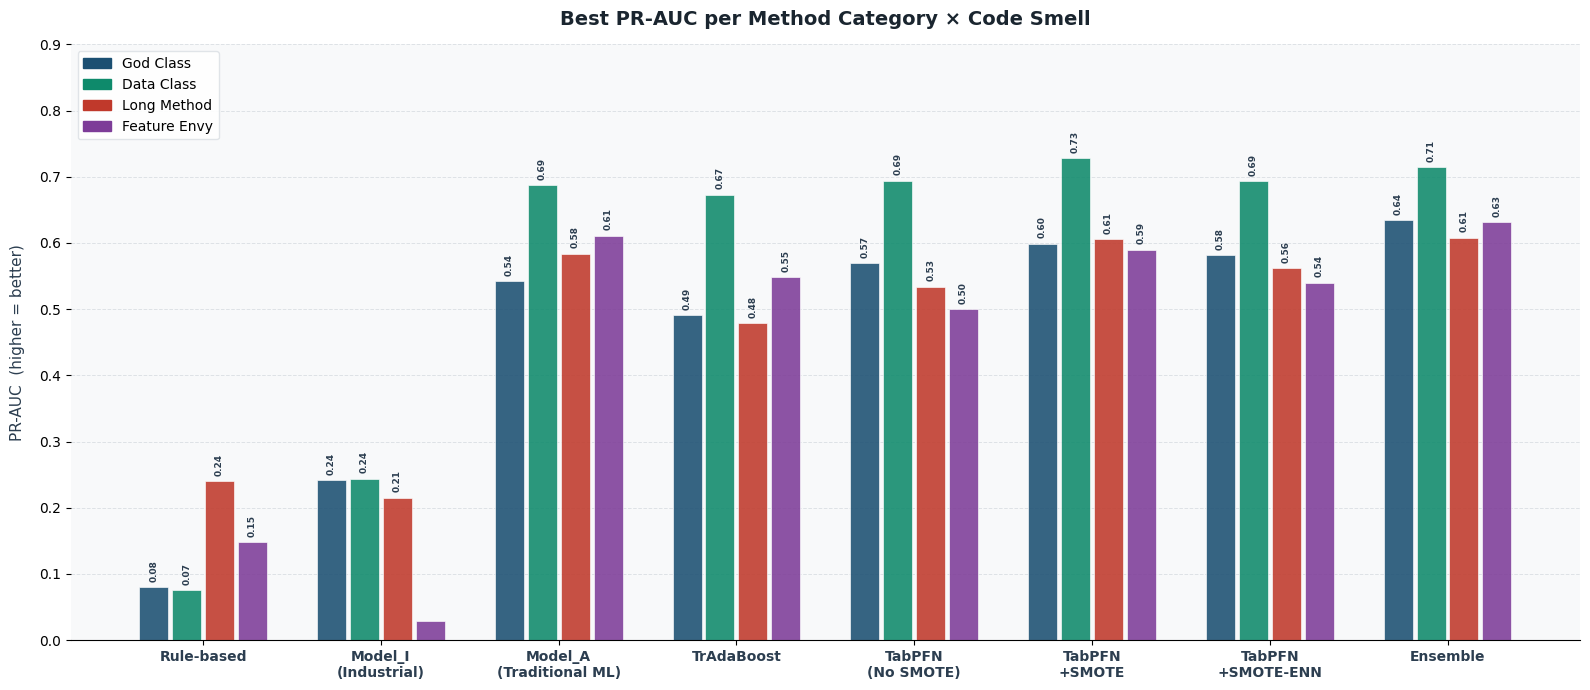

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plot1_grouped_bar.png


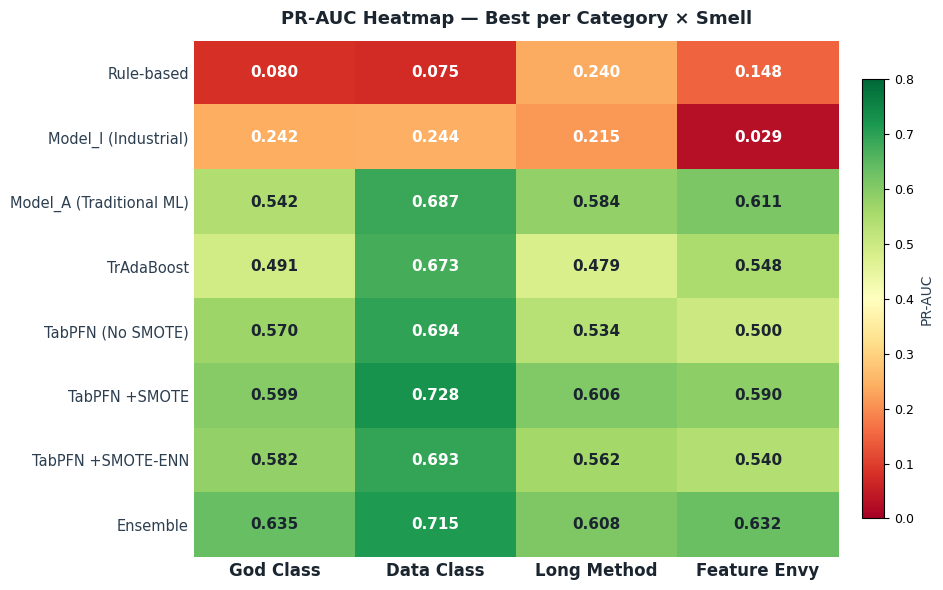

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plot2_heatmap.png


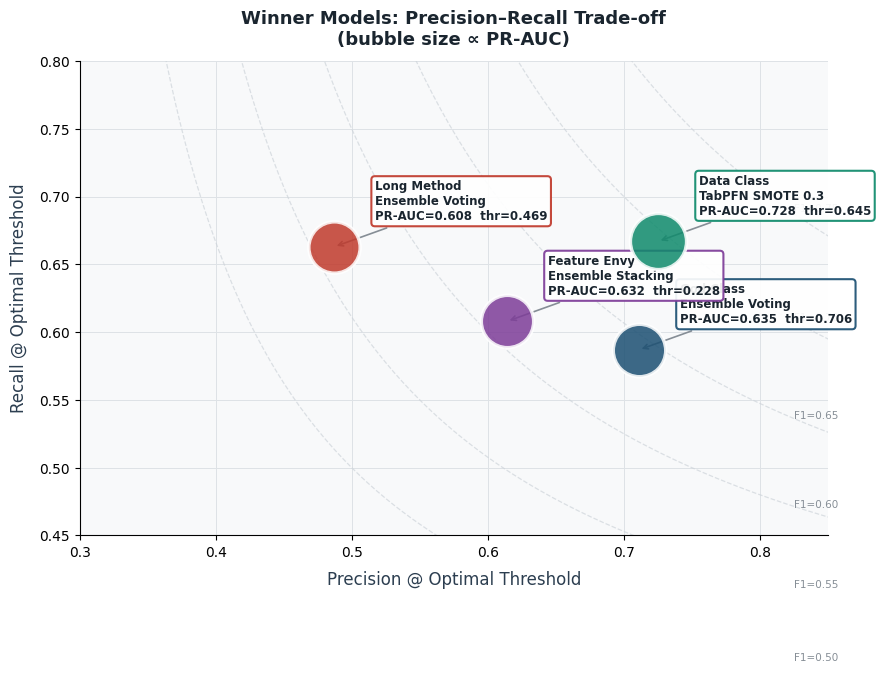

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plot3_precision_recall_winners.png


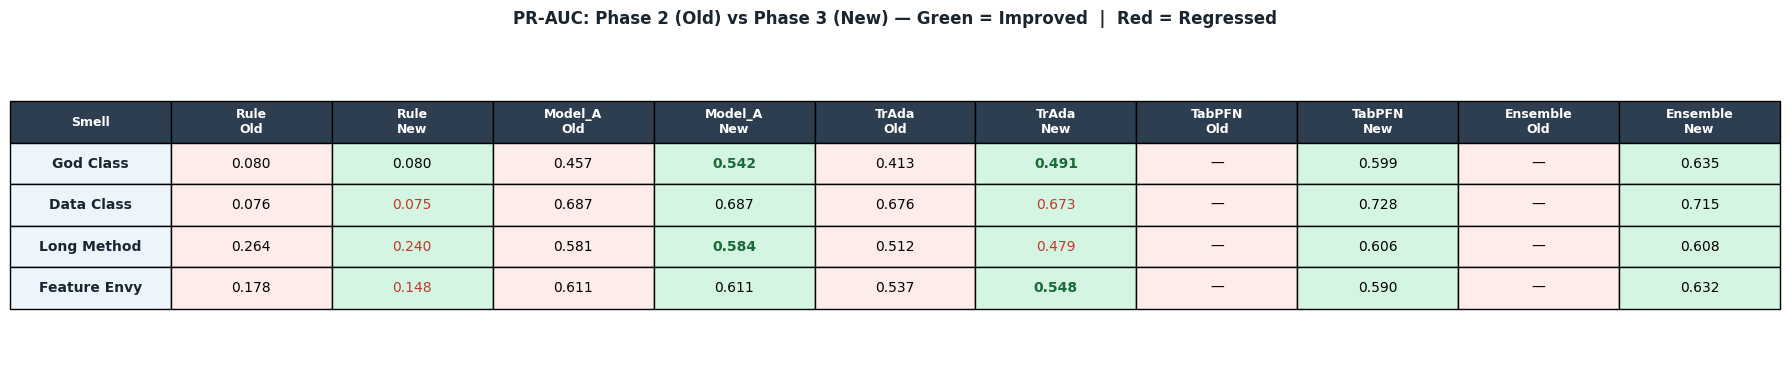

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plot4_old_vs_new_table.png

✅ All 4 plots saved to: /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots
  plot1_grouped_bar.png        — grouped bar per category × smell
  plot2_heatmap.png            — PR-AUC heatmap
  plot3_precision_recall_winners.png — P/R trade-off for winners
  plot4_old_vs_new_table.png   — old vs new comparison table


In [ ]:
# ── Presentation Visualizations: Code Smell Detection Results ─────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load CSVs ──────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/CodeSmell_Stage3'
OUT  = '/content/drive/MyDrive/CodeSmell_Stage3/presentation_plots'
import os; os.makedirs(OUT, exist_ok=True)

paths = {
    'God Class':     f'{BASE}/god_class/deployment/god_class_all_results.csv',
    'Data Class':    f'{BASE}/data_class/deployment/data_class_all_results.csv',
    'Long Method':   f'{BASE}/long_method/deployment/long_class_all_results.csv',
    'Feature Envy':  f'{BASE}/feature_envy/deployment/envy_class_all_results.csv',
}

dfs = {}
for smell, path in paths.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['smell'] = smell
    dfs[smell] = df
    print(f"  {smell}: {len(df)} rows | cols: {list(df.columns)}")

# ── Column name normalisation (handles pr_auc / PR_AUC / pr-auc etc.) ────────
def col(df, *candidates):
    for c in candidates:
        matches = [x for x in df.columns if x.lower().replace('-','_') == c.lower().replace('-','_')]
        if matches:
            return matches[0]
    raise KeyError(f"None of {candidates} found in {list(df.columns)}")

# ── 2. Build category-best summary ────────────────────────────────────────────
CATEGORY_MAP = {
    'Rule':              'Rule-based',
    'Model_I':           'Model_I\n(Industrial)',
    'Model_A':           'Model_A\n(Traditional ML)',
    'TrAda':             'TrAdaBoost',
    'TabPFN':            'TabPFN\n(No SMOTE)',
    'TabPFN+SMOTE':      'TabPFN\n+SMOTE',
    'TabPFN+SMOTE-ENN':  'TabPFN\n+SMOTE-ENN',
    'Ensemble':          'Ensemble',
}

summary_rows = []
for smell, df in dfs.items():
    pr_col  = col(df, 'pr_auc', 'PR_AUC', 'pr-auc')
    cat_col = col(df, 'category', 'Category')
    f1_col  = col(df, 'f1_o', 'F1_opt', 'f1_opt')
    p_col   = col(df, 'pr_o', 'Prec_opt', 'prec_opt')
    r_col   = col(df, 're_o', 'Rec_opt', 'rec_opt')
    for cat in df[cat_col].unique():
        sub  = df[df[cat_col] == cat]
        best = sub.loc[sub[pr_col].idxmax()]
        summary_rows.append({
            'smell':    smell,
            'category': cat,
            'pr_auc':   round(float(best[pr_col]), 3),
            'f1':       round(float(best[f1_col]), 3),
            'prec':     round(float(best[p_col]),  3),
            'rec':      round(float(best[r_col]),  3),
            'model':    best[col(df, 'Model', 'model')],
        })

summary = pd.DataFrame(summary_rows)

# ── Palette ───────────────────────────────────────────────────────────────────
SMELL_COLORS = {
    'God Class':    '#1B4F72',
    'Data Class':   '#0E8A6B',
    'Long Method':  '#C0392B',
    'Feature Envy': '#7D3C98',
}
CAT_COLORS = {
    'Rule':             '#BDC3C7',
    'Model_I':          '#85929E',
    'Model_A':          '#2E86C1',
    'TrAda':            '#1ABC9C',
    'TabPFN':           '#F39C12',
    'TabPFN+SMOTE':     '#E74C3C',
    'TabPFN+SMOTE-ENN': '#C0392B',
    'Ensemble':         '#8E44AD',
}

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Grouped bar: Best PR-AUC per category × smell
# ══════════════════════════════════════════════════════════════════════════════
PLOT_CATS = ['Rule', 'Model_I', 'Model_A', 'TrAda',
             'TabPFN', 'TabPFN+SMOTE', 'TabPFN+SMOTE-ENN', 'Ensemble']
SMELLS    = ['God Class', 'Data Class', 'Long Method', 'Feature Envy']

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

n_cats  = len(PLOT_CATS)
n_smell = len(SMELLS)
bar_w   = 0.10
group_w = n_smell * bar_w + 0.06
x_base  = np.arange(n_cats) * (group_w + 0.08)

for si, smell in enumerate(SMELLS):
    xs, ys = [], []
    for ci, cat in enumerate(PLOT_CATS):
        row = summary[(summary.smell == smell) & (summary.category == cat)]
        val = float(row['pr_auc'].values[0]) if len(row) else 0.0
        x   = x_base[ci] + si * bar_w
        xs.append(x)
        ys.append(val)
        bar = ax.bar(x, val, width=bar_w * 0.88,
                     color=SMELL_COLORS[smell], alpha=0.88,
                     edgecolor='white', linewidth=0.5)
        if val > 0.05:
            ax.text(x, val + 0.008, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=6.5,
                    color='#2C3E50', fontweight='bold', rotation=90)

# x-axis labels centred on each group
ax.set_xticks(x_base + (n_smell - 1) * bar_w / 2)
ax.set_xticklabels([CATEGORY_MAP.get(c, c) for c in PLOT_CATS],
                   fontsize=10, fontweight='bold', color='#2C3E50')
ax.set_ylabel('PR-AUC  (higher = better)', fontsize=11, color='#2C3E50', labelpad=10)
ax.set_title('Best PR-AUC per Method Category × Code Smell',
             fontsize=14, fontweight='bold', color='#1A252F', pad=14)
ax.set_ylim(0, 0.90)
ax.yaxis.grid(True, color='#DEE2E6', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)

legend_patches = [mpatches.Patch(color=SMELL_COLORS[s], label=s) for s in SMELLS]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10,
          framealpha=0.9, edgecolor='#DEE2E6')

plt.tight_layout()
p1 = f'{OUT}/plot1_grouped_bar.png'
plt.savefig(p1, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {p1}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Heatmap: PR-AUC for all categories × smells
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

pivot = summary.pivot_table(index='category', columns='smell',
                             values='pr_auc', aggfunc='max')
pivot = pivot.reindex(index=PLOT_CATS, columns=SMELLS)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

cmap   = plt.cm.RdYlGn
norm   = mcolors.Normalize(vmin=0.0, vmax=0.80)
im     = ax.imshow(pivot.values.astype(float), cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(SMELLS)))
ax.set_xticklabels(SMELLS, fontsize=12, fontweight='bold', color='#1A252F')
ax.set_yticks(range(len(PLOT_CATS)))
ax.set_yticklabels([CATEGORY_MAP.get(c, c).replace('\n', ' ')
                    for c in PLOT_CATS], fontsize=10.5, color='#2C3E50')

for i in range(len(PLOT_CATS)):
    for j in range(len(SMELLS)):
        val = pivot.values[i, j]
        if np.isnan(val):
            ax.text(j, i, '—', ha='center', va='center', fontsize=11, color='#95A5A6')
        else:
            brightness = norm(val)
            txt_color  = 'white' if brightness < 0.45 or brightness > 0.82 else '#1A252F'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=txt_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label('PR-AUC', fontsize=10, color='#2C3E50')
cbar.ax.tick_params(labelsize=9)

ax.set_title('PR-AUC Heatmap — Best per Category × Smell',
             fontsize=13, fontweight='bold', color='#1A252F', pad=12)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
p2 = f'{OUT}/plot2_heatmap.png'
plt.savefig(p2, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {p2}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Precision vs Recall scatter for WINNER of each smell
# ══════════════════════════════════════════════════════════════════════════════
winners = []
for smell, df in dfs.items():
    pr_col  = col(df, 'pr_auc', 'PR_AUC')
    f1_col  = col(df, 'f1_o', 'F1_opt', 'f1_opt')
    p_col   = col(df, 'pr_o', 'Prec_opt', 'prec_opt')
    r_col   = col(df, 're_o', 'Rec_opt', 'rec_opt')
    m_col   = col(df, 'Model', 'model')
    t_col   = col(df, 'opt_thr', 'Opt_Thresh', 'opt_thresh')
    best    = df.loc[df[pr_col].idxmax()]
    winners.append({
        'smell':  smell,
        'model':  best[m_col],
        'pr_auc': float(best[pr_col]),
        'f1':     float(best[f1_col]),
        'prec':   float(best[p_col]),
        'rec':    float(best[r_col]),
        'thresh': float(best[t_col]),
    })

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')
ax.set_xlim(0.30, 0.85); ax.set_ylim(0.45, 0.80)

# F1 iso-curves
for f1_iso in [0.5, 0.55, 0.6, 0.65, 0.70, 0.75]:
    p_range = np.linspace(0.05, 0.99, 300)
    r_iso   = f1_iso * p_range / (2 * p_range - f1_iso + 1e-9)
    mask    = (r_iso > 0) & (r_iso < 1) & (p_range > 0) & (p_range < 1)
    ax.plot(p_range[mask], r_iso[mask], color='#CED4DA',
            linewidth=0.9, linestyle='--', alpha=0.7)
    idx = np.argmin(np.abs(p_range[mask] - 0.82))
    ax.text(p_range[mask][idx] + 0.005, r_iso[mask][idx],
            f'F1={f1_iso:.2f}', fontsize=7.5, color='#868E96', va='center')

for w in winners:
    size = (w['pr_auc'] / 0.80) * 1800
    ax.scatter(w['prec'], w['rec'], s=size, color=SMELL_COLORS[w['smell']],
               alpha=0.85, edgecolors='white', linewidths=2.5, zorder=5)
    ax.annotate(
        f"{w['smell']}\n{w['model'].replace('_', ' ')}\nPR-AUC={w['pr_auc']:.3f}  thr={w['thresh']:.3f}",
        xy=(w['prec'], w['rec']),
        xytext=(w['prec'] + 0.03, w['rec'] + 0.02),
        fontsize=8.5, color='#1A252F', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#868E96', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=SMELL_COLORS[w['smell']], linewidth=1.5, alpha=0.92)
    )

ax.set_xlabel('Precision @ Optimal Threshold', fontsize=12,
              color='#2C3E50', labelpad=8)
ax.set_ylabel('Recall @ Optimal Threshold', fontsize=12,
              color='#2C3E50', labelpad=8)
ax.set_title('Winner Models: Precision–Recall Trade-off\n(bubble size ∝ PR-AUC)',
             fontsize=13, fontweight='bold', color='#1A252F', pad=12)
ax.yaxis.grid(True, color='#DEE2E6', linewidth=0.7)
ax.xaxis.grid(True, color='#DEE2E6', linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
p3 = f'{OUT}/plot3_precision_recall_winners.png'
plt.savefig(p3, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {p3}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Old vs New PR-AUC improvement table (rendered as figure)
# ══════════════════════════════════════════════════════════════════════════════
OLD = {
    'God Class':   {'Rule': 0.080, 'Model_A': 0.457, 'TrAda': 0.413},
    'Data Class':  {'Rule': 0.076, 'Model_A': 0.687, 'TrAda': 0.676},
    'Long Method': {'Rule': 0.264, 'Model_A': 0.581, 'TrAda': 0.512},
    'Feature Envy':{'Rule': 0.178, 'Model_A': 0.611, 'TrAda': 0.537},
}

rows_tbl = []
for smell in SMELLS:
    df   = dfs[smell]
    pr_c = col(df, 'pr_auc', 'PR_AUC')
    c_c  = col(df, 'category', 'Category')
    m_c  = col(df, 'Model', 'model')
    def best_pr(cat_filter):
        sub = df[df[c_c].isin(cat_filter)] if isinstance(cat_filter, list) else df[df[c_c]==cat_filter]
        return round(float(sub[pr_c].max()), 3) if len(sub) else 0.0
    new_rule   = best_pr('Rule')
    new_mod_a  = best_pr('Model_A')
    new_trada  = best_pr('TrAda')
    new_tabpfn = best_pr(['TabPFN','TabPFN+SMOTE','TabPFN+SMOTE-ENN'])
    new_ens    = best_pr('Ensemble')
    new_best   = df.loc[df[pr_c].idxmax(), m_c]
    rows_tbl.append([
        smell,
        f"{OLD[smell]['Rule']:.3f}",
        f"{new_rule:.3f}",
        f"{OLD[smell]['Model_A']:.3f}",
        f"{new_mod_a:.3f}",
        f"{OLD[smell]['TrAda']:.3f}",
        f"{new_trada:.3f}",
        f"—",
        f"{new_tabpfn:.3f}",
        f"—",
        f"{new_ens:.3f}",
    ])

col_labels = [
    'Smell',
    'Rule\nOld','Rule\nNew',
    'Model_A\nOld','Model_A\nNew',
    'TrAda\nOld','TrAda\nNew',
    'TabPFN\nOld','TabPFN\nNew',
    'Ensemble\nOld','Ensemble\nNew',
]

fig, ax = plt.subplots(figsize=(18, 4))
fig.patch.set_facecolor('white')
ax.axis('off')

tbl = ax.table(
    cellText=rows_tbl,
    colLabels=col_labels,
    cellLoc='center', loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.2)

HEADER_PAIRS = [(1,2),(3,4),(5,6),(7,8),(9,10)]
HDR_COLORS   = ['#ECF0F1','#D5DBDB','#EBF5FB','#E8F8F5','#F4ECF7']
NEW_COLOR     = '#D5F5E3'
OLD_COLOR     = '#FDECEA'

for col_idx, label in enumerate(col_labels):
    cell = tbl[0, col_idx]
    cell.set_facecolor('#2C3E50')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)

for row_idx in range(1, len(rows_tbl)+1):
    tbl[row_idx, 0].set_facecolor('#EBF5FB')
    tbl[row_idx, 0].set_text_props(fontweight='bold', color='#1A252F')
    for old_c, new_c in HEADER_PAIRS:
        tbl[row_idx, old_c].set_facecolor(OLD_COLOR)
        tbl[row_idx, new_c].set_facecolor(NEW_COLOR)
        old_v = rows_tbl[row_idx-1][old_c]
        new_v = rows_tbl[row_idx-1][new_c]
        if old_v != '—' and new_v != '—':
            if float(new_v) > float(old_v):
                tbl[row_idx, new_c].set_text_props(fontweight='bold', color='#1A6B3A')
            elif float(new_v) < float(old_v):
                tbl[row_idx, new_c].set_text_props(color='#C0392B')

ax.set_title('PR-AUC: Phase 2 (Old) vs Phase 3 (New) — Green = Improved  |  Red = Regressed',
             fontsize=12, fontweight='bold', color='#1A252F', pad=10, y=0.98)

plt.tight_layout()
p4 = f'{OUT}/plot4_old_vs_new_table.png'
plt.savefig(p4, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {p4}")

# ══════════════════════════════════════════════════════════════════════════════
print("\n✅ All 4 plots saved to:", OUT)
print("  plot1_grouped_bar.png        — grouped bar per category × smell")
print("  plot2_heatmap.png            — PR-AUC heatmap")
print("  plot3_precision_recall_winners.png — P/R trade-off for winners")
print("  plot4_old_vs_new_table.png   — old vs new comparison table")

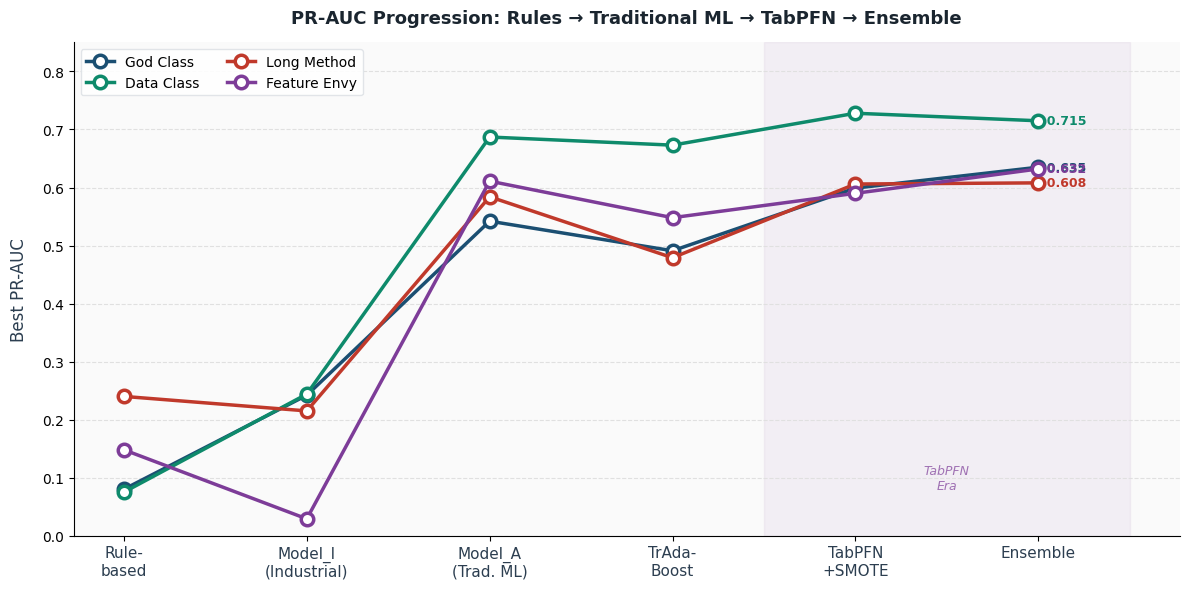

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plotA_progression.png


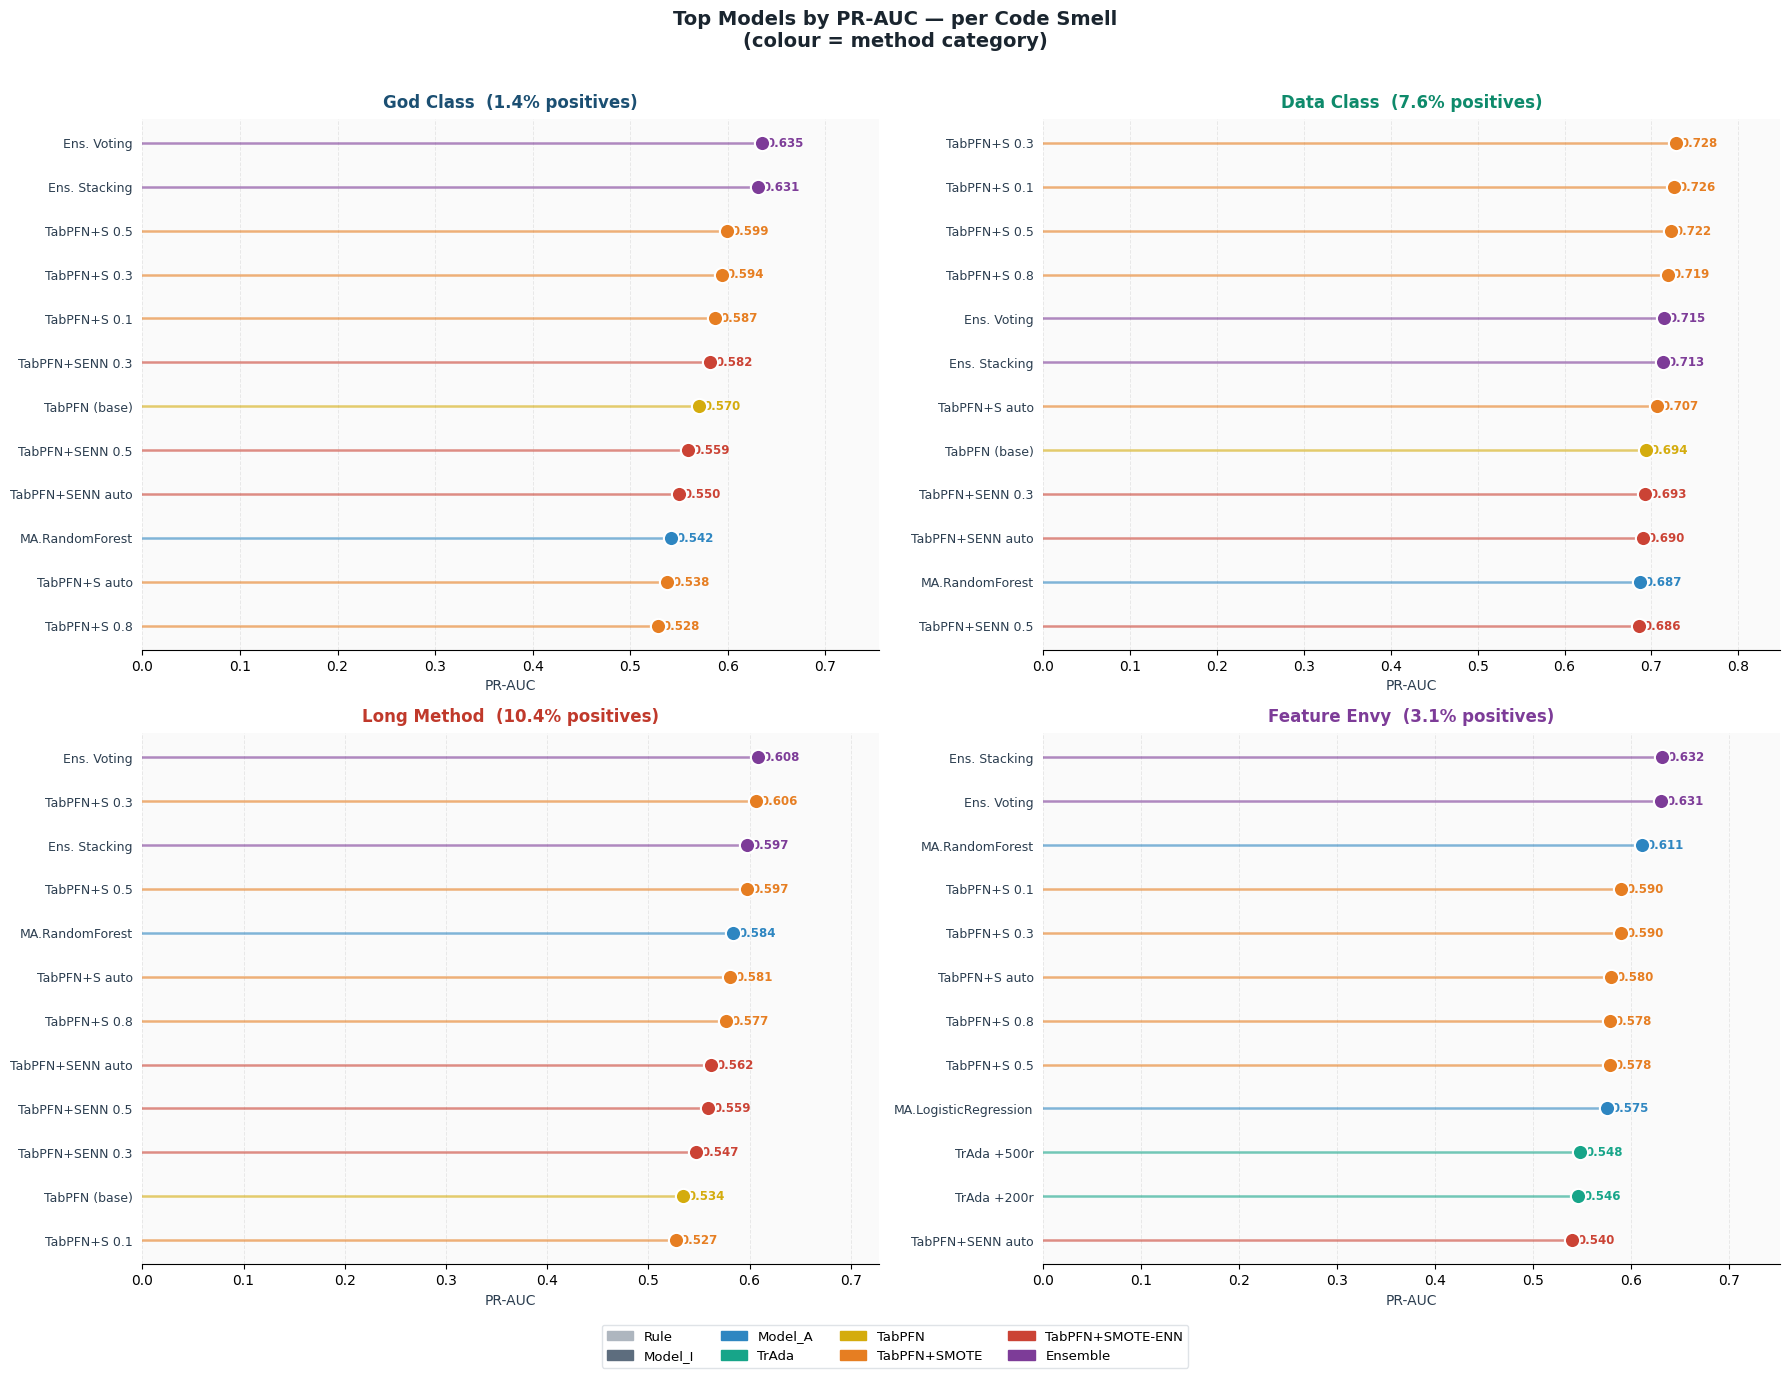

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plotB_lollipop.png


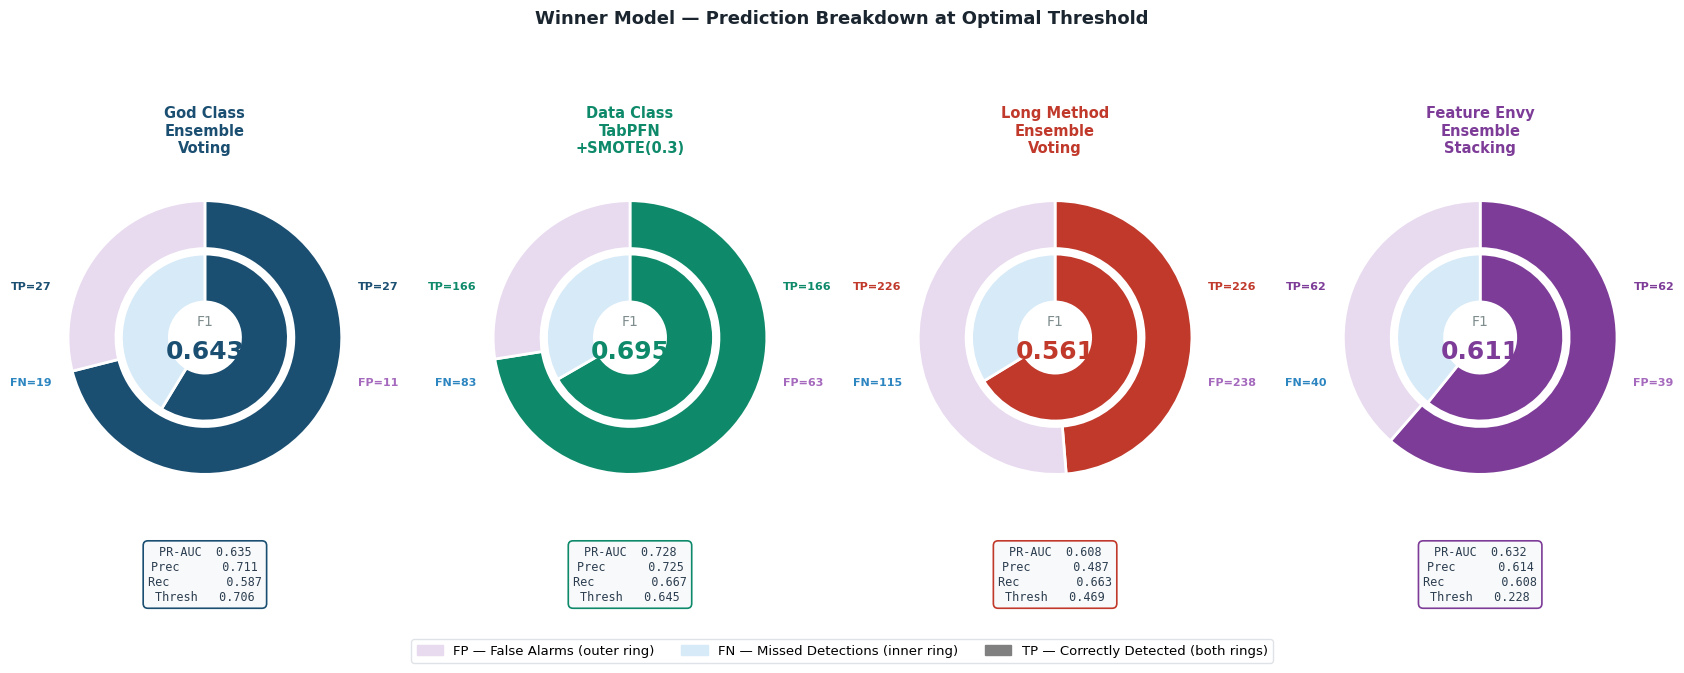

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plotC_winner_breakdown.png

✅ Done.
  /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plotA_progression.png
  /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plotB_lollipop.png
  /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/plotC_winner_breakdown.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


# ── 1. Load CSVs ──────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/CodeSmell_Stage3'
OUT  = '/content/drive/MyDrive/CodeSmell_Stage3/presentation_plots'
import os; os.makedirs(OUT, exist_ok=True)

paths = {
    'God Class':     f'{BASE}/god_class/deployment/god_class_all_results.csv',
    'Data Class':    f'{BASE}/data_class/deployment/data_class_all_results.csv',
    'Long Method':   f'{BASE}/long_method/deployment/long_class_all_results.csv',
    'Feature Envy':  f'{BASE}/feature_envy/deployment/envy_class_all_results.csv',
}

dfs = {}
for smell, path in paths.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    dfs[smell] = df

def gc(df, *names):
    for n in names:
        m = [c for c in df.columns if c.lower().replace('-','_') == n.lower().replace('-','_')]
        if m: return m[0]
    raise KeyError(names)

SMELLS = ['God Class', 'Data Class', 'Long Method', 'Feature Envy']
SMELL_COLORS = {
    'God Class':    '#1B4F72',
    'Data Class':   '#0E8A6B',
    'Long Method':  '#C0392B',
    'Feature Envy': '#7D3C98',
}
CAT_COLORS = {
    'Rule':             '#AEB6BF',
    'Model_I':          '#5D6D7E',
    'Model_A':          '#2E86C1',
    'TrAda':            '#17A589',
    'TabPFN':           '#D4AC0D',
    'TabPFN+SMOTE':     '#E67E22',
    'TabPFN+SMOTE-ENN': '#CB4335',
    'Ensemble':         '#7D3C98',
}

# ══════════════════════════════════════════════════════════════════════════════
# PLOT A — Method Progression: PR-AUC journey from Rules → Ensemble
# Shows the narrative arc for each smell
# ══════════════════════════════════════════════════════════════════════════════

STAGES = ['Rule', 'Model_I', 'Model_A', 'TrAda', 'TabPFN+SMOTE', 'Ensemble']
STAGE_LABELS = ['Rule-\nbased', 'Model_I\n(Industrial)', 'Model_A\n(Trad. ML)',
                'TrAda-\nBoost', 'TabPFN\n+SMOTE', 'Ensemble']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFAFA')

for smell in SMELLS:
    df     = dfs[smell]
    pr_col = gc(df, 'pr_auc', 'PR_AUC')
    c_col  = gc(df, 'category', 'Category')

    ys = []
    for stage in STAGES:
        if stage == 'TabPFN+SMOTE':
            cats = ['TabPFN', 'TabPFN+SMOTE', 'TabPFN+SMOTE-ENN']
            sub  = df[df[c_col].isin(cats)]
        else:
            sub  = df[df[c_col] == stage]
        val = float(sub[pr_col].max()) if len(sub) else np.nan
        ys.append(val)

    xs = range(len(STAGES))
    ax.plot(xs, ys, color=SMELL_COLORS[smell], linewidth=2.5,
            marker='o', markersize=9, markerfacecolor='white',
            markeredgewidth=2.5, markeredgecolor=SMELL_COLORS[smell],
            label=smell, zorder=4)

    # annotate final point
    ax.annotate(f"  {ys[-1]:.3f}", xy=(len(STAGES)-1, ys[-1]),
                fontsize=9, color=SMELL_COLORS[smell],
                fontweight='bold', va='center')

# shade improvement zone
ax.axvspan(3.5, 5.5, alpha=0.06, color='#7D3C98', zorder=0)
ax.text(4.5, 0.08, 'TabPFN\nEra', ha='center', fontsize=9,
        color='#7D3C98', alpha=0.7, style='italic')

ax.set_xticks(range(len(STAGES)))
ax.set_xticklabels(STAGE_LABELS, fontsize=11, color='#2C3E50')
ax.set_ylabel('Best PR-AUC', fontsize=12, color='#2C3E50', labelpad=10)
ax.set_title('PR-AUC Progression: Rules → Traditional ML → TabPFN → Ensemble',
             fontsize=13, fontweight='bold', color='#1A252F', pad=14)
ax.set_ylim(0.0, 0.85)
ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9,
          edgecolor='#DEE2E6', ncol=2)

plt.tight_layout()
pA = f'{OUT}/plotA_progression.png'
plt.savefig(pA, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {pA}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT B — Lollipop small multiples: Top 12 models per smell
# Clean ranked view, color = method category
# ══════════════════════════════════════════════════════════════════════════════

TOP_N = 12

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.patch.set_facecolor('white')
fig.suptitle('Top Models by PR-AUC — per Code Smell\n(colour = method category)',
             fontsize=14, fontweight='bold', color='#1A252F', y=1.01)

for ax, smell in zip(axes.flat, SMELLS):
    df     = dfs[smell]
    pr_col = gc(df, 'pr_auc', 'PR_AUC')
    c_col  = gc(df, 'category', 'Category')
    m_col  = gc(df, 'Model', 'model')

    top = df.nlargest(TOP_N, pr_col).reset_index(drop=True)
    top = top.iloc[::-1].reset_index(drop=True)   # flip so best is at top

    ys   = range(len(top))
    vals = top[pr_col].astype(float).values
    cats = top[c_col].values
    mods = top[m_col].values

    # clean model name for display
    def short(name):
        name = name.replace('TabPFN_SMOTEENN_', 'TabPFN+SENN ')
        name = name.replace('TabPFN_SMOTE_', 'TabPFN+S ')
        name = name.replace('TabPFN_NoSMOTE', 'TabPFN (base)')
        name = name.replace('Ensemble_', 'Ens. ')
        name = name.replace('Model_A_', 'MA.')
        name = name.replace('Model_I_', 'MI.')
        name = name.replace('TrAda_+', 'TrAda +')
        name = name.replace('Rule', 'Rule')
        return name

    colors = [CAT_COLORS.get(c, '#95A5A6') for c in cats]

    ax.set_facecolor('#FAFAFA')

    for i, (y, val, col_c, mod) in enumerate(zip(ys, vals, colors, mods)):
        ax.plot([0, val], [y, y], color=col_c, linewidth=1.8,
                alpha=0.6, zorder=2)
        ax.scatter(val, y, color=col_c, s=120, zorder=4,
                   edgecolors='white', linewidths=1.5)
        ax.text(val + 0.005, y, f'{val:.3f}', va='center',
                fontsize=8.5, color=col_c, fontweight='bold')

    ax.set_yticks(ys)
    ax.set_yticklabels([short(m) for m in mods], fontsize=9, color='#2C3E50')
    ax.set_xlabel('PR-AUC', fontsize=10, color='#2C3E50')
    ax.set_xlim(0, max(vals) + 0.12)
    ax.xaxis.grid(True, color='#E8E8E8', linewidth=0.7, linestyle='--')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)

    pos_rate = {'God Class':'1.4%','Data Class':'7.6%',
                'Long Method':'10.4%','Feature Envy':'3.1%'}[smell]
    ax.set_title(f'{smell}  ({pos_rate} positives)',
                 fontsize=12, fontweight='bold',
                 color=SMELL_COLORS[smell], pad=8)

# shared legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9.5, framealpha=0.95, edgecolor='#DEE2E6',
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
pB = f'{OUT}/plotB_lollipop.png'
plt.savefig(pB, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {pB}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT C — Winner breakdown: TP / FP / FN for each smell's best model
# Shows operational reality — what the model actually does
# ══════════════════════════════════════════════════════════════════════════════

win_data = []
for smell in SMELLS:
    df      = dfs[smell]
    pr_col  = gc(df, 'pr_auc', 'PR_AUC')
    m_col   = gc(df, 'Model', 'model')
    tp_col  = gc(df, 'tp', 'TP')
    fp_col  = gc(df, 'fp', 'FP')
    fn_col  = gc(df, 'fn', 'FN')
    f1_col  = gc(df, 'f1_o', 'F1_opt', 'f1_opt')
    p_col   = gc(df, 'pr_o', 'Prec_opt', 'prec_opt')
    r_col   = gc(df, 're_o', 'Rec_opt', 'rec_opt')
    t_col   = gc(df, 'opt_thr', 'Opt_Thresh', 'opt_thresh')
    best    = df.loc[df[pr_col].idxmax()]
    win_data.append({
        'smell':  smell,
        'model':  best[m_col],
        'tp':     int(best[tp_col]),
        'fp':     int(best[fp_col]),
        'fn':     int(best[fn_col]),
        'pr_auc': float(best[pr_col]),
        'f1':     float(best[f1_col]),
        'prec':   float(best[p_col]),
        'rec':    float(best[r_col]),
        'thresh': float(best[t_col]),
    })

fig, axes = plt.subplots(1, 4, figsize=(17, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Winner Model — Prediction Breakdown at Optimal Threshold',
             fontsize=13, fontweight='bold', color='#1A252F', y=1.02)

for ax, w in zip(axes, win_data):
    ax.set_facecolor('white')
    total_pos  = w['tp'] + w['fn']
    total_pred = w['tp'] + w['fp']

    # Donut: inner = ground truth (TP vs FN), outer = predictions (TP vs FP)
    size   = 0.35
    c_main = SMELL_COLORS[w['smell']]

    outer_vals  = [w['tp'], w['fp']]
    outer_cols  = [c_main, '#E8DAEF']
    inner_vals  = [w['tp'], w['fn']]
    inner_cols  = [c_main, '#D6EAF8']

    ax.pie(outer_vals, radius=1.0, colors=outer_cols,
           startangle=90, counterclock=False,
           wedgeprops=dict(width=size, edgecolor='white', linewidth=2))
    ax.pie(inner_vals, radius=1.0-size-0.04, colors=inner_cols,
           startangle=90, counterclock=False,
           wedgeprops=dict(width=size, edgecolor='white', linewidth=2))

    # centre text
    ax.text(0, 0.12, f'F1', ha='center', va='center',
            fontsize=10, color='#7F8C8D')
    ax.text(0, -0.10, f'{w["f1"]:.3f}', ha='center', va='center',
            fontsize=18, fontweight='bold', color=c_main)

    # labels outside
    def short_model(name):
        if 'Ensemble_Voting'   in name: return 'Ensemble\nVoting'
        if 'Ensemble_Stacking' in name: return 'Ensemble\nStacking'
        if 'TabPFN_SMOTE_'     in name: return 'TabPFN\n+SMOTE(' + name.split('_')[-1] + ')'
        if 'Model_A_'          in name: return 'Model_A\n' + name.split('_')[-1]
        return name.replace('_', '\n')

    ax.set_title(f'{w["smell"]}\n{short_model(w["model"])}',
                 fontsize=10.5, fontweight='bold',
                 color=SMELL_COLORS[w['smell']], pad=10)

    metrics = (f'PR-AUC  {w["pr_auc"]:.3f}\n'
               f'Prec      {w["prec"]:.3f}\n'
               f'Rec        {w["rec"]:.3f}\n'
               f'Thresh   {w["thresh"]:.3f}')
    ax.text(0, -1.52, metrics, ha='center', va='top',
            fontsize=8.5, color='#2C3E50',
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8F9FA',
                      edgecolor=c_main, linewidth=1.2))

    # ring labels
    ax.text(1.12, 0.35, f'TP={w["tp"]}', fontsize=8,
            color=c_main, fontweight='bold', ha='left')
    ax.text(1.12, -0.35, f'FP={w["fp"]}', fontsize=8,
            color='#A569BD', fontweight='bold', ha='left')
    ax.text(-1.12, 0.35, f'TP={w["tp"]}', fontsize=8,
            color=c_main, fontweight='bold', ha='right')
    ax.text(-1.12, -0.35, f'FN={w["fn"]}', fontsize=8,
            color='#2E86C1', fontweight='bold', ha='right')

# legend rings
legend_els = [
    mpatches.Patch(color='#E8DAEF', label='FP — False Alarms (outer ring)'),
    mpatches.Patch(color='#D6EAF8', label='FN — Missed Detections (inner ring)'),
    mpatches.Patch(color='grey',    label='TP — Correctly Detected (both rings)'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=3,
           fontsize=9.5, framealpha=0.95, edgecolor='#DEE2E6',
           bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
pC = f'{OUT}/plotC_winner_breakdown.png'
plt.savefig(pC, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print(f"Saved → {pC}")

print("\n✅ Done.")
print(f"  {pA}")
print(f"  {pB}")
print(f"  {pC}")

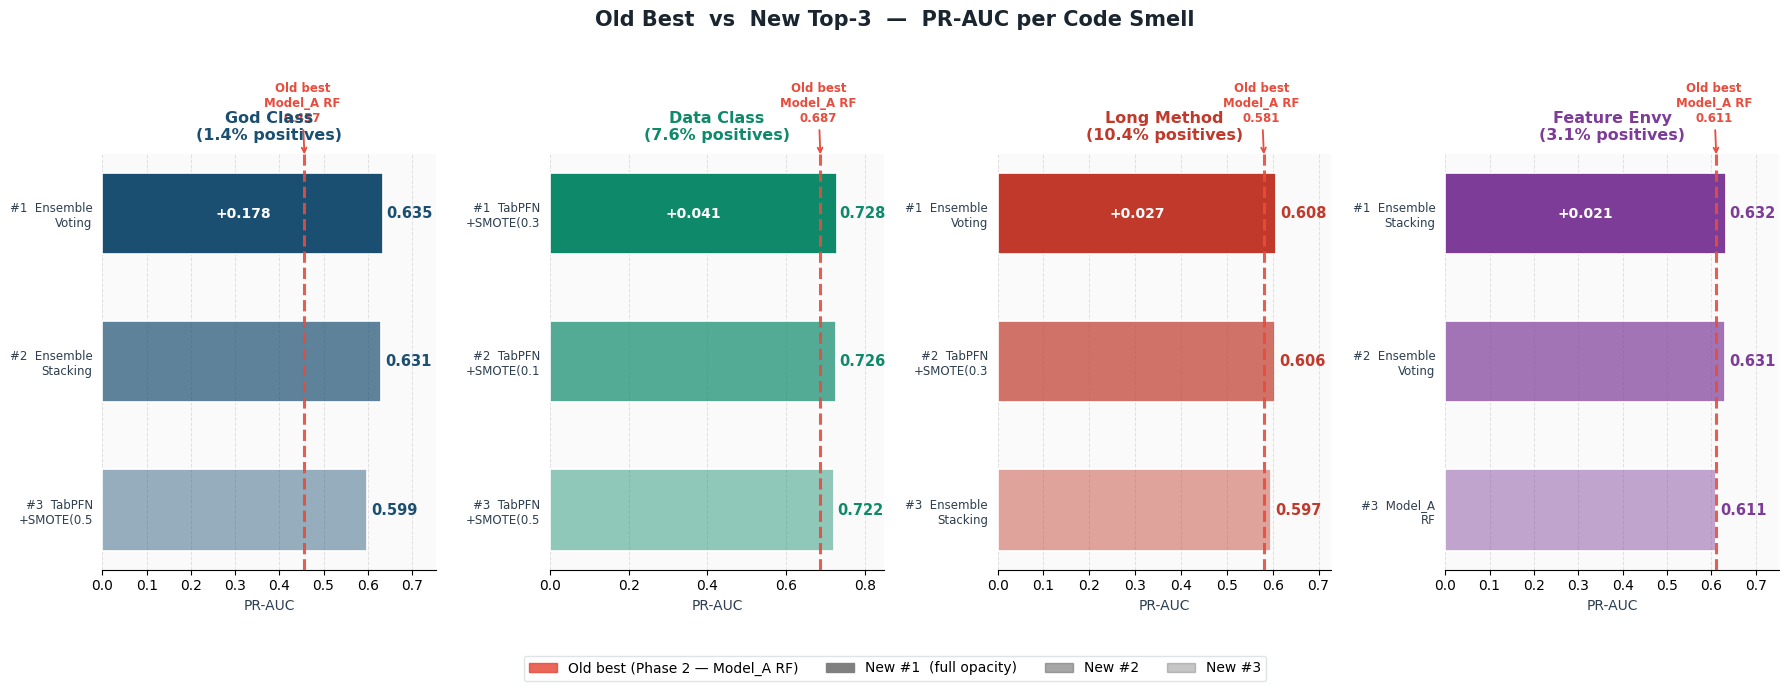

Saved → /content/drive/MyDrive/CodeSmell_Stage3/presentation_plots/comparison_old_vs_new_top3.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# BASE = '/content/drive/MyDrive/CodeSmell_Stage3'
# OUT  = '/content/drive/MyDrive/CodeSmell_Stage3/presentation_plots'
# import os; os.makedirs(OUT, exist_ok=True)

# # ── Load CSVs ─────────────────────────────────────────────────────────────────
# paths = {
#     'God Class':    f'{BASE}/god_class/deployment/god_class_all_results.csv',
#     'Data Class':   f'{BASE}/data_class/deployment/data_class_all_results.csv',
#     'Long Method':  f'{BASE}/long_method/deployment/long_method_all_results.csv',
#     'Feature Envy': f'{BASE}/feature_envy/deployment/feature_envy_all_results.csv',
# }
dfs = {s: pd.read_csv(p) for s, p in paths.items()}
for df in dfs.values(): df.columns = df.columns.str.strip()

def gc(df, *names):
    for n in names:
        m = [c for c in df.columns if c.lower().replace('-','_') == n.lower().replace('-','_')]
        if m: return m[0]
    raise KeyError(names)

# ── Old best per smell (Phase 2: best of Rule/Model_I/Model_A/TrAda) ──────────
OLD_BEST = {
    'God Class':    ('Model_A RF',   0.457),
    'Data Class':   ('Model_A RF',   0.687),
    'Long Method':  ('Model_A RF',   0.581),
    'Feature Envy': ('Model_A RF',   0.611),
}

# ── Extract new top-3 from each CSV ──────────────────────────────────────────
SMELLS = ['God Class', 'Data Class', 'Long Method', 'Feature Envy']

def short(name):
    replacements = [
        ('Ensemble_Voting',         'Ensemble\nVoting'),
        ('Ensemble_Stacking',       'Ensemble\nStacking'),
        ('TabPFN_SMOTEENN_',        'TabPFN\n+SENN('),
        ('TabPFN_SMOTE_',           'TabPFN\n+SMOTE('),
        ('TabPFN_NoSMOTE',          'TabPFN\n(base)'),
        ('Model_A_RandomForest',    'Model_A\nRF'),
        ('Model_A_XGBoost',         'Model_A\nXGB'),
        ('Model_A_LogisticRegression','Model_A\nLR'),
        ('TrAda_+',                 'TrAda\n+'),
    ]
    for old, new in replacements:
        if old in name:
            name = name.replace(old, new)
            if name.endswith('('):
                name = name + '?)'
            return name
    return name.replace('_', '\n')

new_top3 = {}
for smell, df in dfs.items():
    pr_col = gc(df, 'pr_auc', 'PR_AUC')
    m_col  = gc(df, 'Model', 'model')
    top3   = df.nlargest(3, pr_col)[[m_col, pr_col]].reset_index(drop=True)
    new_top3[smell] = [
        (short(top3.loc[i, m_col]), round(float(top3.loc[i, pr_col]), 3))
        for i in range(3)
    ]

# ══════════════════════════════════════════════════════════════════════════════
# PLOT — Old best  vs  New #1 / #2 / #3
# Layout: 4 panels (one per smell), horizontal bars, old shown as reference line
# ══════════════════════════════════════════════════════════════════════════════

SMELL_COLORS = {
    'God Class':    '#1B4F72',
    'Data Class':   '#0E8A6B',
    'Long Method':  '#C0392B',
    'Feature Envy': '#7D3C98',
}
RANK_ALPHA = [1.0, 0.70, 0.45]   # opacity for #1, #2, #3

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)
fig.patch.set_facecolor('white')
fig.suptitle('Old Best  vs  New Top-3  —  PR-AUC per Code Smell',
             fontsize=15, fontweight='bold', color='#1A252F', y=1.03)

for ax, smell in zip(axes, SMELLS):
    ax.set_facecolor('#FAFAFA')
    color      = SMELL_COLORS[smell]
    old_label, old_val = OLD_BEST[smell]
    top3       = new_top3[smell]

    bar_labels = [f'#{i+1}  {lbl}' for i, (lbl, _) in enumerate(top3)]
    bar_vals   = [v for _, v in top3]
    bar_colors = [(*plt.matplotlib.colors.to_rgb(color), a) for a in RANK_ALPHA]

    # determine axis max
    xmax = max(bar_vals + [old_val]) + 0.12

    y_pos = [2, 1, 0]   # #1 at top
    bars  = ax.barh(y_pos, bar_vals, color=bar_colors,
                    height=0.55, edgecolor='white', linewidth=1.2, zorder=3)

    # value labels on bars
    for y, val in zip(y_pos, bar_vals):
        ax.text(val + 0.008, y, f'{val:.3f}',
                va='center', ha='left', fontsize=10.5,
                fontweight='bold', color=color)

    # old best — vertical dashed line
    ax.axvline(old_val, color='#E74C3C', linewidth=2.2,
               linestyle='--', zorder=4, alpha=0.9)

    # old best annotation (arrow + label at top)
    ax.annotate(
        f'Old best\n{old_label}\n{old_val:.3f}',
        xy=(old_val, 2.38),
        xytext=(old_val - 0.005, 2.62),
        ha='center', fontsize=8.5, color='#E74C3C', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.3),
        annotation_clip=False,
    )

    # improvement badge on #1 bar
    delta = bar_vals[0] - old_val
    sign  = '+' if delta >= 0 else ''
    badge_color = '#1A6B3A' if delta >= 0 else '#C0392B'
    ax.text(bar_vals[0] / 2, 2,
            f'{sign}{delta:.3f}',
            va='center', ha='center', fontsize=10,
            fontweight='bold', color='white', zorder=5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bar_labels, fontsize=8.5, color='#2C3E50')
    ax.set_xlim(0, xmax)
    ax.set_xlabel('PR-AUC', fontsize=10, color='#2C3E50')
    ax.xaxis.grid(True, color='#E0E0E0', linewidth=0.7,
                  linestyle='--', zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(left=False)

    pos_rate = {'God Class':'1.4%', 'Data Class':'7.6%',
                'Long Method':'10.4%', 'Feature Envy':'3.1%'}[smell]
    ax.set_title(f'{smell}\n({pos_rate} positives)',
                 fontsize=11.5, fontweight='bold',
                 color=color, pad=10)

# shared legend
legend_els = [
    mpatches.Patch(color='#E74C3C', alpha=0.85,
                   label='Old best (Phase 2 — Model_A RF)'),
    mpatches.Patch(color='grey', alpha=1.0,  label='New #1  (full opacity)'),
    mpatches.Patch(color='grey', alpha=0.70, label='New #2'),
    mpatches.Patch(color='grey', alpha=0.45, label='New #3'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=4,
           fontsize=10, framealpha=0.95, edgecolor='#DEE2E6',
           bbox_to_anchor=(0.5, -0.10))

plt.tight_layout()
out = f'{OUT}/comparison_old_vs_new_top3.png'
plt.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved → {out}")